<h1>Required functions</h1>

In [1]:
#Visualize data output
import matplotlib.pyplot as plt
import json
import statistics

In [2]:
QD = [2**i for i in range(9)]
PROCESS = [1,2,4,8]
WORKLOAD = ["randread","randwrite","read","write"]
MARKERS = [ "d", "^" , "X", "P","<",">","o","h","+"]
CALLS=0
BAR_COLOR = "springgreen"
CPU_COLOR = {
    'usr':"lightskyblue",
    'sys':"steelblue",
    'io':"black",
}

def plot_lat_percentile(experiment, name, percentile = 0,div=1, ax = None):
    if ax is None:
        ax = plt.gca()
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v) for k, v in data.items()}
    y = [i for i in data.keys() if i >= percentile]
    x = [data[i]/div for i in y]
    # Plot CDF
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    print(experiment, data)
    ax.plot(x, y, '-'+mark,label=name)
    ax.grid(True)

def plot_lat_line(experiments, percentile, names):
    points = []
    for exp in experiments:
        if percentile is "max":
            data = op[exp]['latency']
        else:
            data = op[exp]['latency']['percentile']
            data = {float(k): float(v) for k, v in data.items()}
        points.append(data[percentile]/1000)
    print(percentile, points)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(names, points, '-'+mark, label=percentile)

def plot_lat_bar(experiment, name, ax, pos):
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v)/10**3 for k, v in data.items()}
    boxes = [
        {
            'label' : name,
            'whislo': data[5.00],    # Bottom whisker position
            'q1'    : data[20.0],    # First quartile (25th percentile)
            'med'   : data[50.0],    # Median         (50th percentile)
            'q3'    : data[80.0],    # Third quartile (75th percentile)
            'whishi': data[95.00],    # Top whisker position
            'fliers': []        # Outliers
        }
    ]
    print(boxes)
    ax.bxp(boxes,positions=[pos])
    plt.xlabel("Experiment")
    plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
    plt.grid(True, 'both','y')

def plot_ctx_line(experiments,x,label):
    obs = []
    for exp in experiments:
        y = op[exp]['fio_cpu']['ctx']
        y = y / 1000
        obs.append(y)
    print(label, obs)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(x,obs,'-'+mark,label=label)
    plt.grid(True)

def plot_iops_line(experiments,x,label):
    obs = []
    for exp in experiments:
        y = op[exp]['iops']['mean']
        y = y / 1000
        obs.append(y)
    print(label, obs)
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(x,obs,'-'+mark,label=label)
    plt.grid(True)

def plot_iops_bar(experiment, name):
    y = op[experiment]['iops']['mean']
    y = y / 1000
    print(experiment,op[experiment]['iops'])
    plt.bar([name],[y],color=BAR_COLOR)
    plt.ylabel('KIOPS')
    plt.grid(True)

def plot_iops_cpu(experiments):
    pass

def plot_bw_bar(experiment, name):
    y = op[experiment]['bw']['mean']
    y = y/1000
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('Bandwidth (MBps)')
    plt.grid(True)


def cpu_utilization(experiment, name):
    cpu = op[experiment]['fio_cpu']
    print(experiment, cpu)
    bottom=0
    for i in ['usr','sys']:
        plt.bar([name], [cpu[i]],color=CPU_COLOR[i],bottom=bottom, label=i)
        bottom += cpu[i]
    plt.xlabel("Experiment")
    plt.ylabel('CPU utilization')
    plt.grid(True)

def cpu_init_utilization(experiment, name, plot_cpu):
    cpu = op[experiment]['init_cpu']
    print(experiment, cpu)

    if plot_cpu == -1:
        plot_cpu="all"
    else:
        plot_cpu = str(plot_cpu)

    bottom=0
    for i in ['usr','sys','io']:
        plt.bar([name], [float(cpu[plot_cpu][i])],color=CPU_COLOR[i],bottom=bottom, label=i)
        bottom += float(cpu[plot_cpu][i])
    plt.xlabel("Experiment")
    plt.ylabel('CPU utilization')
    plt.grid(True)

def cpu_target_utilization(experiments, name):
    cpu = op[experiment]['target_cpu']
    print(experiment, cpu)
    bottom=0
    plot_cpu = 'all'
    plot_cpu_util = 0
    for i in cpu.keys():
        if i != 'all':
            util = float(cpu[i]['sys'])
            if util > plot_cpu_util:
                plot_cpu = i
                plot_cpu_util = util

    for i in ['sys']:
        plt.bar([name], [float(cpu[plot_cpu][i])], color=CPU_COLOR[i], bottom=bottom, label=i)
        bottom += float(cpu[plot_cpu][i])
        
    plt.xlabel("Experiment")
    plt.ylabel('CPU utilization')
    plt.grid(True)

def plot_iops_ts(file, name, lim=-1):
    try:
        f = open(file,'r')
    except:
        return
    
    numbers = []
    obs = []
    prev_ts = 0
    for i in f.readlines():
        try:
            ts = int(i.split(",")[0])
            if prev_ts > ts:
                numbers = []
                obs.append(numbers)
            prev_ts = ts
            numbers.append(int(i.split(",")[1])/1000)
        except:
            pass
    obs.append(numbers)
    obs = [sum(i) for i in zip(*obs)]
    plt.plot(obs[:lim],label=name)
    print(name, statistics.median(obs), statistics.mean(obs))
    #plt.axhline(y=statistics.median(obs), linestyle='dashed')
    #plt.axhline(y=statistics.mean(obs), linestyle='dotted')

def plot_lat_iops(experiments, percentile, names):
    dic = {}
    for exp,name in zip(experiments, names):
        iops = op[exp]['iops']['mean']
        data = op[exp]['latency']['percentile']
        data = {float(k): float(v) for k, v in data.items()}
        dic[name] = [data[percentile]/1000, iops/1000]
    return dic
        



<>:31: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:31: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipykernel_26203/40814255.py:31: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if percentile is "max":


<h1>Performance</h1>

In [3]:
fp = open("./performance/crunched_numbers_performance.json")
op = json.load(fp)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in PROCESS:
    for j in QD:
        try:
            plot_iops_bar("local_SSD_randwrite_QD{}_P{}".format(j,i),"QD{}P{}".format(j,i))
        except:
            pass
plt.title('IOPS bar graph for random write operation')

In [ ]:
BAR_COLOR="springgreen"

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
for i in QD:
    plot_iops_bar("local_SSD_randread_QD{}_P1".format(i),"QD{}".format(i))
plt.title('IOPS vs queue depths 1P (random read on local setup)')
plt.xlabel("Queue depths")

In [ ]:
BAR_COLOR="springgreen"

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
for i in QD:
    plot_iops_bar("remote_poll_iou_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('IOPS vs queue depths 1P.4KB.iou (random read on remote(NVMeoF-TCP) setup)')
plt.xlabel("Queue depths")

In [ ]:
BAR_COLOR="springgreen"

fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
for i in QD:
    plot_iops_bar("remote_poll_iou+p_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('IOPS vs queue depths 1P.4KB.iou+p (random read on remote(NVMeoF-TCP) setup)')
plt.xlabel("Queue depths")

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_utilization("local_SSD_randread_QD{}_P1".format(i),"QD{}".format(i))
plt.title('CPU utilization vs queue depths')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_utilization("remote_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('CPU utilization at initiator for different queue depths (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

npoll_iou [927.698, 1222.978, 1576.763, 1775.882, 1858.721, 1657.215, 1514.609, 1823.382, 2661.867]
npoll_ioup [982.299, 1292.291, 1672.477, 1873.068, 1986.551, 2069.987, 2092.063, 2157.253, 3036.943]
poll_ioup [48.135, 38.403, 37.444, 18.62, 30.686, 98.393, 260.172, 320.651, 3407.5]


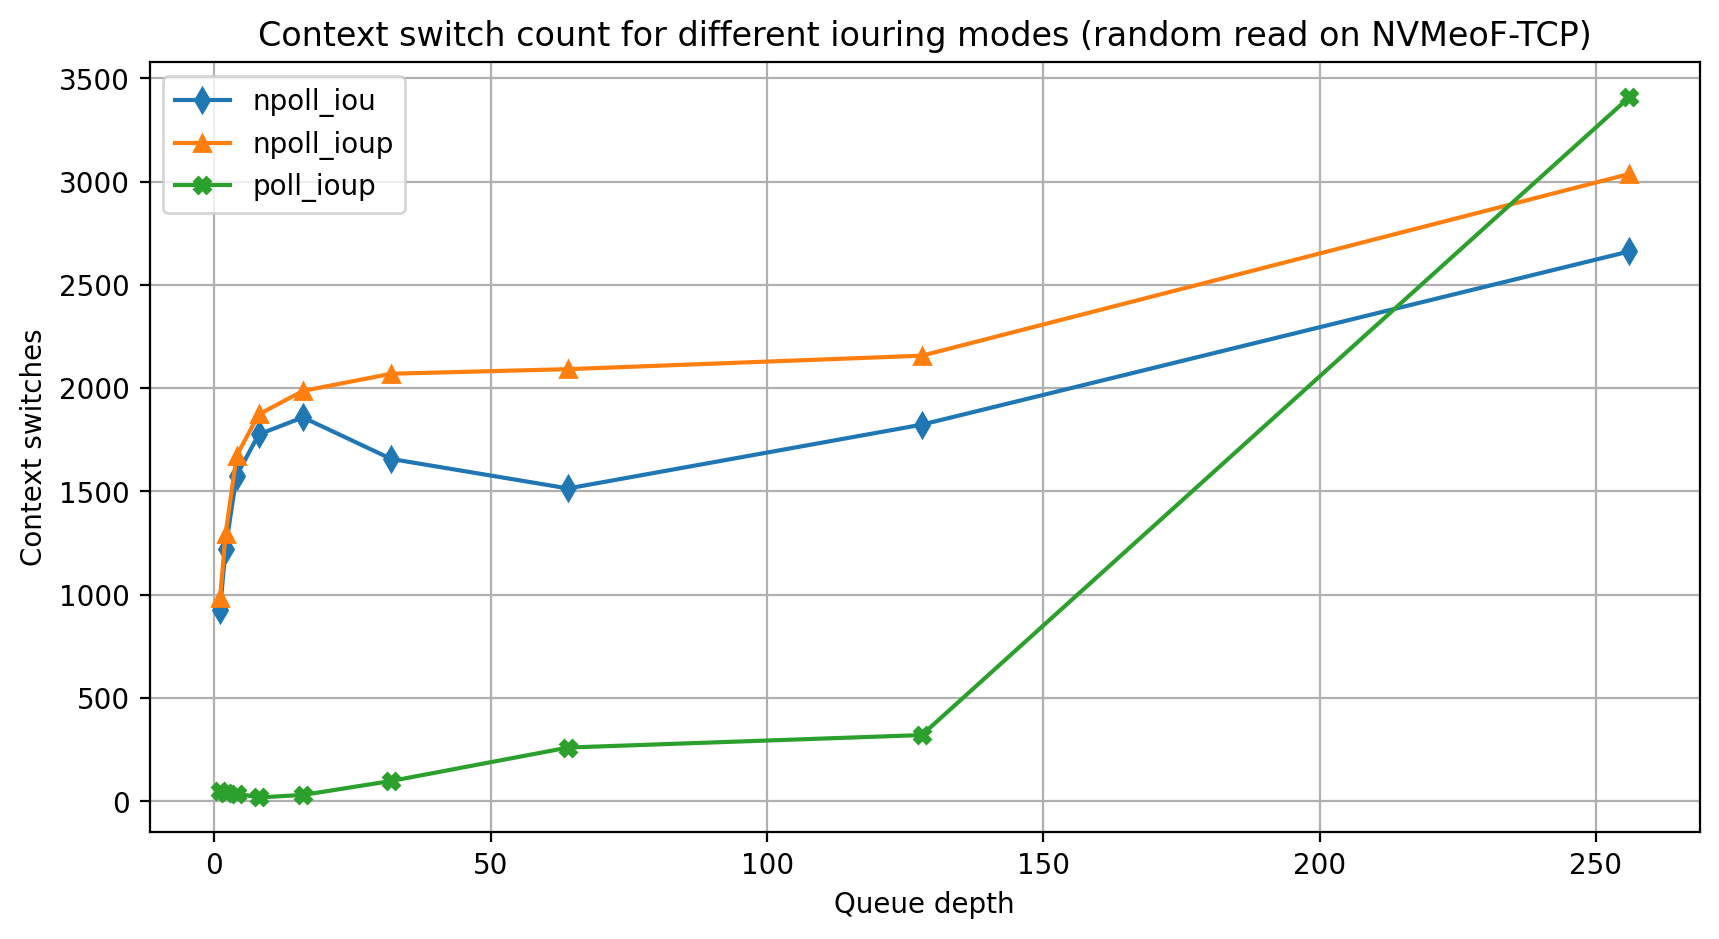

In [15]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["npoll_iou","npoll_ioup","poll_ioup"]:
    experiments=[]
    for i in QD:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_ctx_line(experiments, QD, "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('Context switch count for different iouring modes (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('Context switches')
plt.legend()

remote_npoll_iou_SSD_randread_QD1_P1_4k {'all': {'usr': '0.21', 'sys': '1.22', 'io': '8.32'}, '0': {'usr': '1.71', 'sys': '11.86', 'io': '86.37'}, '1': {'usr': '0.11', 'sys': '0.12', 'io': '0.01'}, '2': {'usr': '0.02', 'sys': '0.08', 'io': '0.10'}, '3': {'usr': '0.04', 'sys': '0.04', 'io': '0.00'}, '4': {'usr': '0.06', 'sys': '0.05', 'io': '0.00'}, '5': {'usr': '0.01', 'sys': '0.01', 'io': '0.00'}, '6': {'usr': '0.01', 'sys': '0.17', 'io': '0.00'}, '7': {'usr': '0.04', 'sys': '0.26', 'io': '0.01'}, '8': {'usr': '0.03', 'sys': '0.03', 'io': '0.00'}, '9': {'usr': '0.14', 'sys': '0.04', 'io': '0.01'}}
remote_npoll_iou_SSD_randread_QD2_P1_4k {'all': {'usr': '0.29', 'sys': '1.71', 'io': '7.55'}, '0': {'usr': '2.67', 'sys': '17.17', 'io': '80.09'}, '1': {'usr': '0.09', 'sys': '0.12', 'io': '0.01'}, '2': {'usr': '0.02', 'sys': '0.06', 'io': '0.00'}, '3': {'usr': '0.03', 'sys': '0.03', 'io': '0.00'}, '4': {'usr': '0.07', 'sys': '0.06', 'io': '0.00'}, '5': {'usr': '0.01', 'sys': '0.01', 'io': '

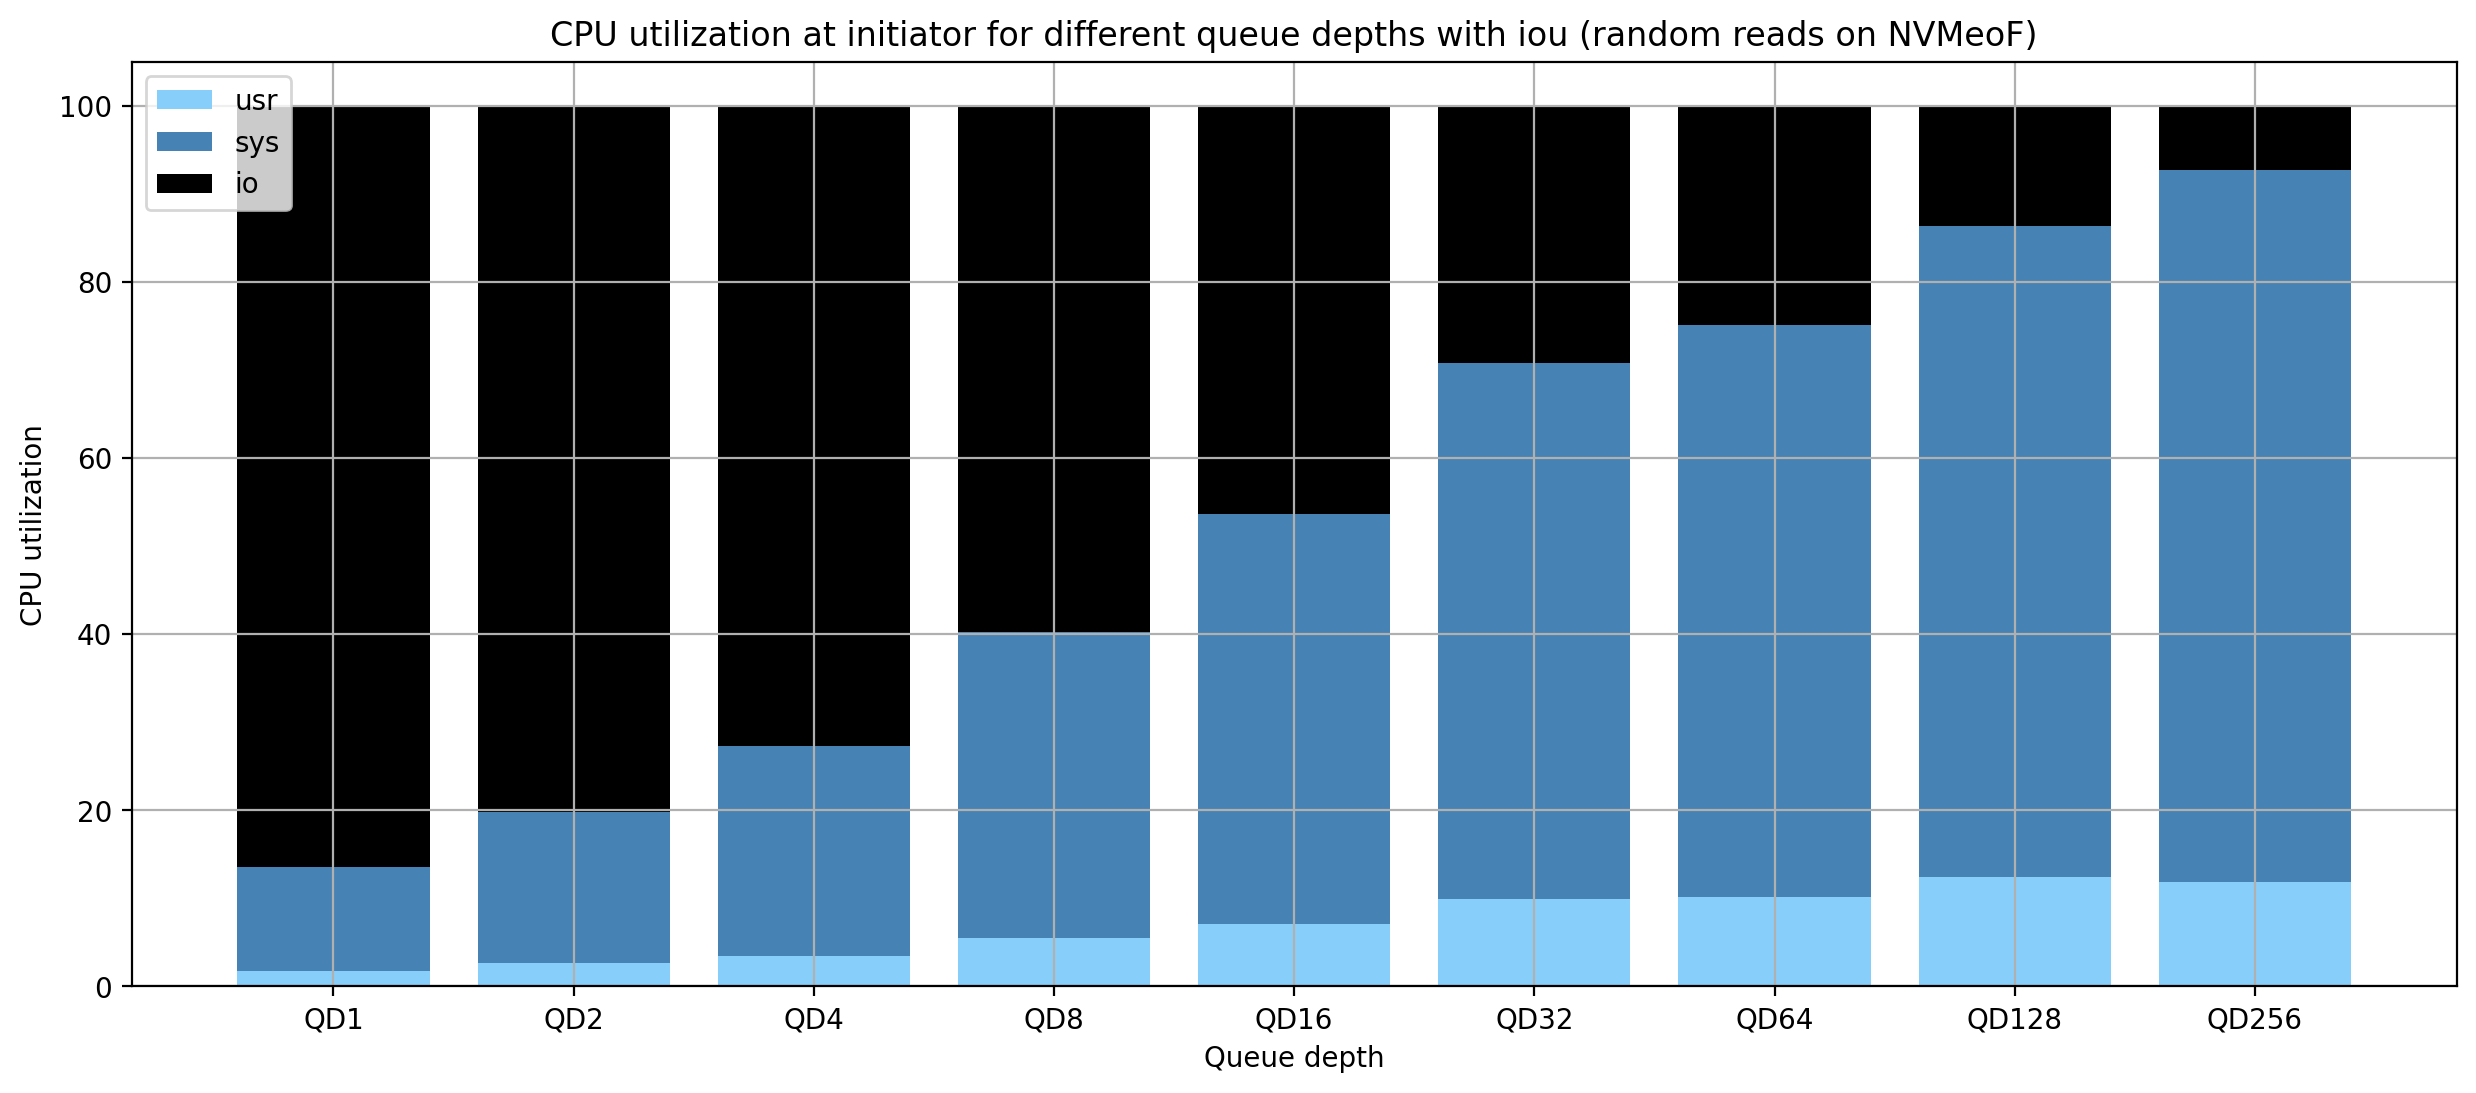

In [7]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_init_utilization("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i), 0)
plt.title('CPU utilization at initiator for different queue depths with iou (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

remote_npoll_ioup_SSD_randread_QD1_P1_4k {'all': {'usr': '0.17', 'sys': '9.99', 'io': '0.01'}, '0': {'usr': '1.28', 'sys': '98.66', 'io': '0.00'}, '1': {'usr': '0.08', 'sys': '0.12', 'io': '0.01'}, '2': {'usr': '0.01', 'sys': '0.04', 'io': '0.00'}, '3': {'usr': '0.08', 'sys': '0.02', 'io': '0.00'}, '4': {'usr': '0.06', 'sys': '0.05', 'io': '0.00'}, '5': {'usr': '0.00', 'sys': '0.01', 'io': '0.00'}, '6': {'usr': '0.01', 'sys': '0.01', 'io': '0.00'}, '7': {'usr': '0.04', 'sys': '0.31', 'io': '0.09'}, '8': {'usr': '0.00', 'sys': '0.01', 'io': '0.00'}, '9': {'usr': '0.11', 'sys': '0.01', 'io': '0.00'}}
remote_npoll_ioup_SSD_randread_QD2_P1_4k {'all': {'usr': '0.26', 'sys': '10.00', 'io': '0.01'}, '0': {'usr': '2.16', 'sys': '97.78', 'io': '0.00'}, '1': {'usr': '0.08', 'sys': '0.09', 'io': '0.00'}, '2': {'usr': '0.02', 'sys': '0.04', 'io': '0.11'}, '3': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '4': {'usr': '0.06', 'sys': '0.07', 'io': '0.00'}, '5': {'usr': '0.01', 'sys': '0.01', 'io': 

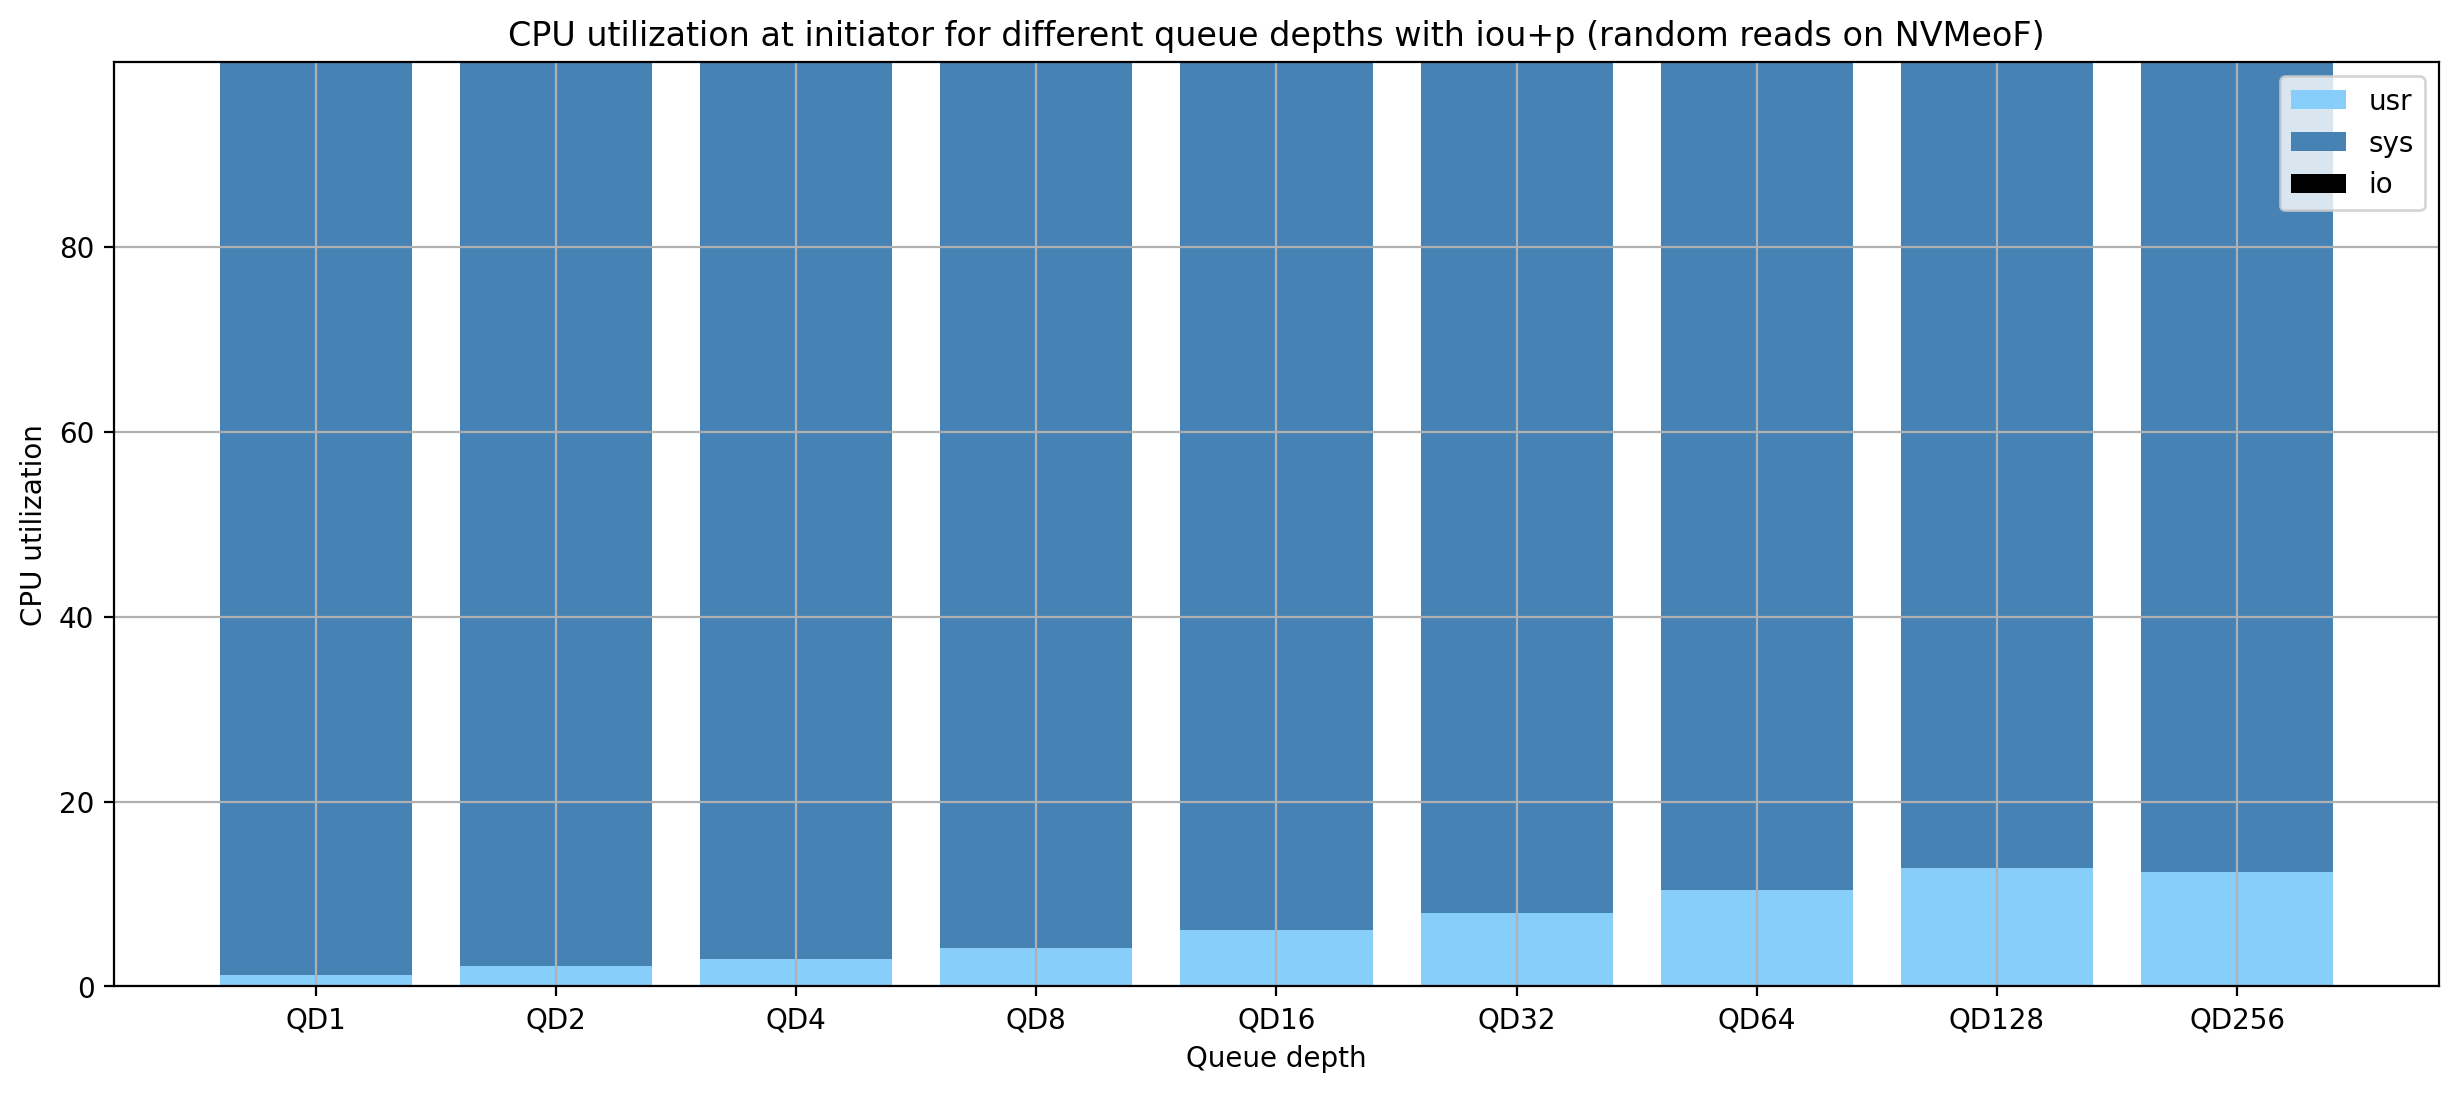

In [25]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_init_utilization("remote_npoll_ioup_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i), 0)
plt.title('CPU utilization at initiator for different queue depths with iou+p (random reads on NVMeoF)')
plt.xlabel("Queue depth")
#plt.yticks([20 * i for i in range(6)])
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

remote_poll_iou_SSD_randread_QD1_P1_4k {'all': {'usr': '0.00', 'sys': '0.63', 'io': '0.00'}, '0': {'usr': '0.01', 'sys': '0.03', 'io': '0.00'}, '1': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '2': {'usr': '0.01', 'sys': '0.02', 'io': '0.01'}, '3': {'usr': '0.00', 'sys': '0.01', 'io': '0.00'}, '4': {'usr': '0.00', 'sys': '0.02', 'io': '0.00'}, '5': {'usr': '0.00', 'sys': '0.04', 'io': '0.00'}, '6': {'usr': '0.00', 'sys': '0.02', 'io': '0.00'}, '7': {'usr': '0.00', 'sys': '0.03', 'io': '0.01'}, '8': {'usr': '0.00', 'sys': '6.80', 'io': '0.00'}, '9': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}}
remote_poll_iou_SSD_randread_QD2_P1_4k {'all': {'usr': '0.00', 'sys': '1.21', 'io': '0.00'}, '0': {'usr': '0.00', 'sys': '0.04', 'io': '0.00'}, '1': {'usr': '0.00', 'sys': '0.07', 'io': '0.01'}, '2': {'usr': '0.00', 'sys': '0.06', 'io': '0.01'}, '3': {'usr': '0.01', 'sys': '0.02', 'io': '0.00'}, '4': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '5': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}

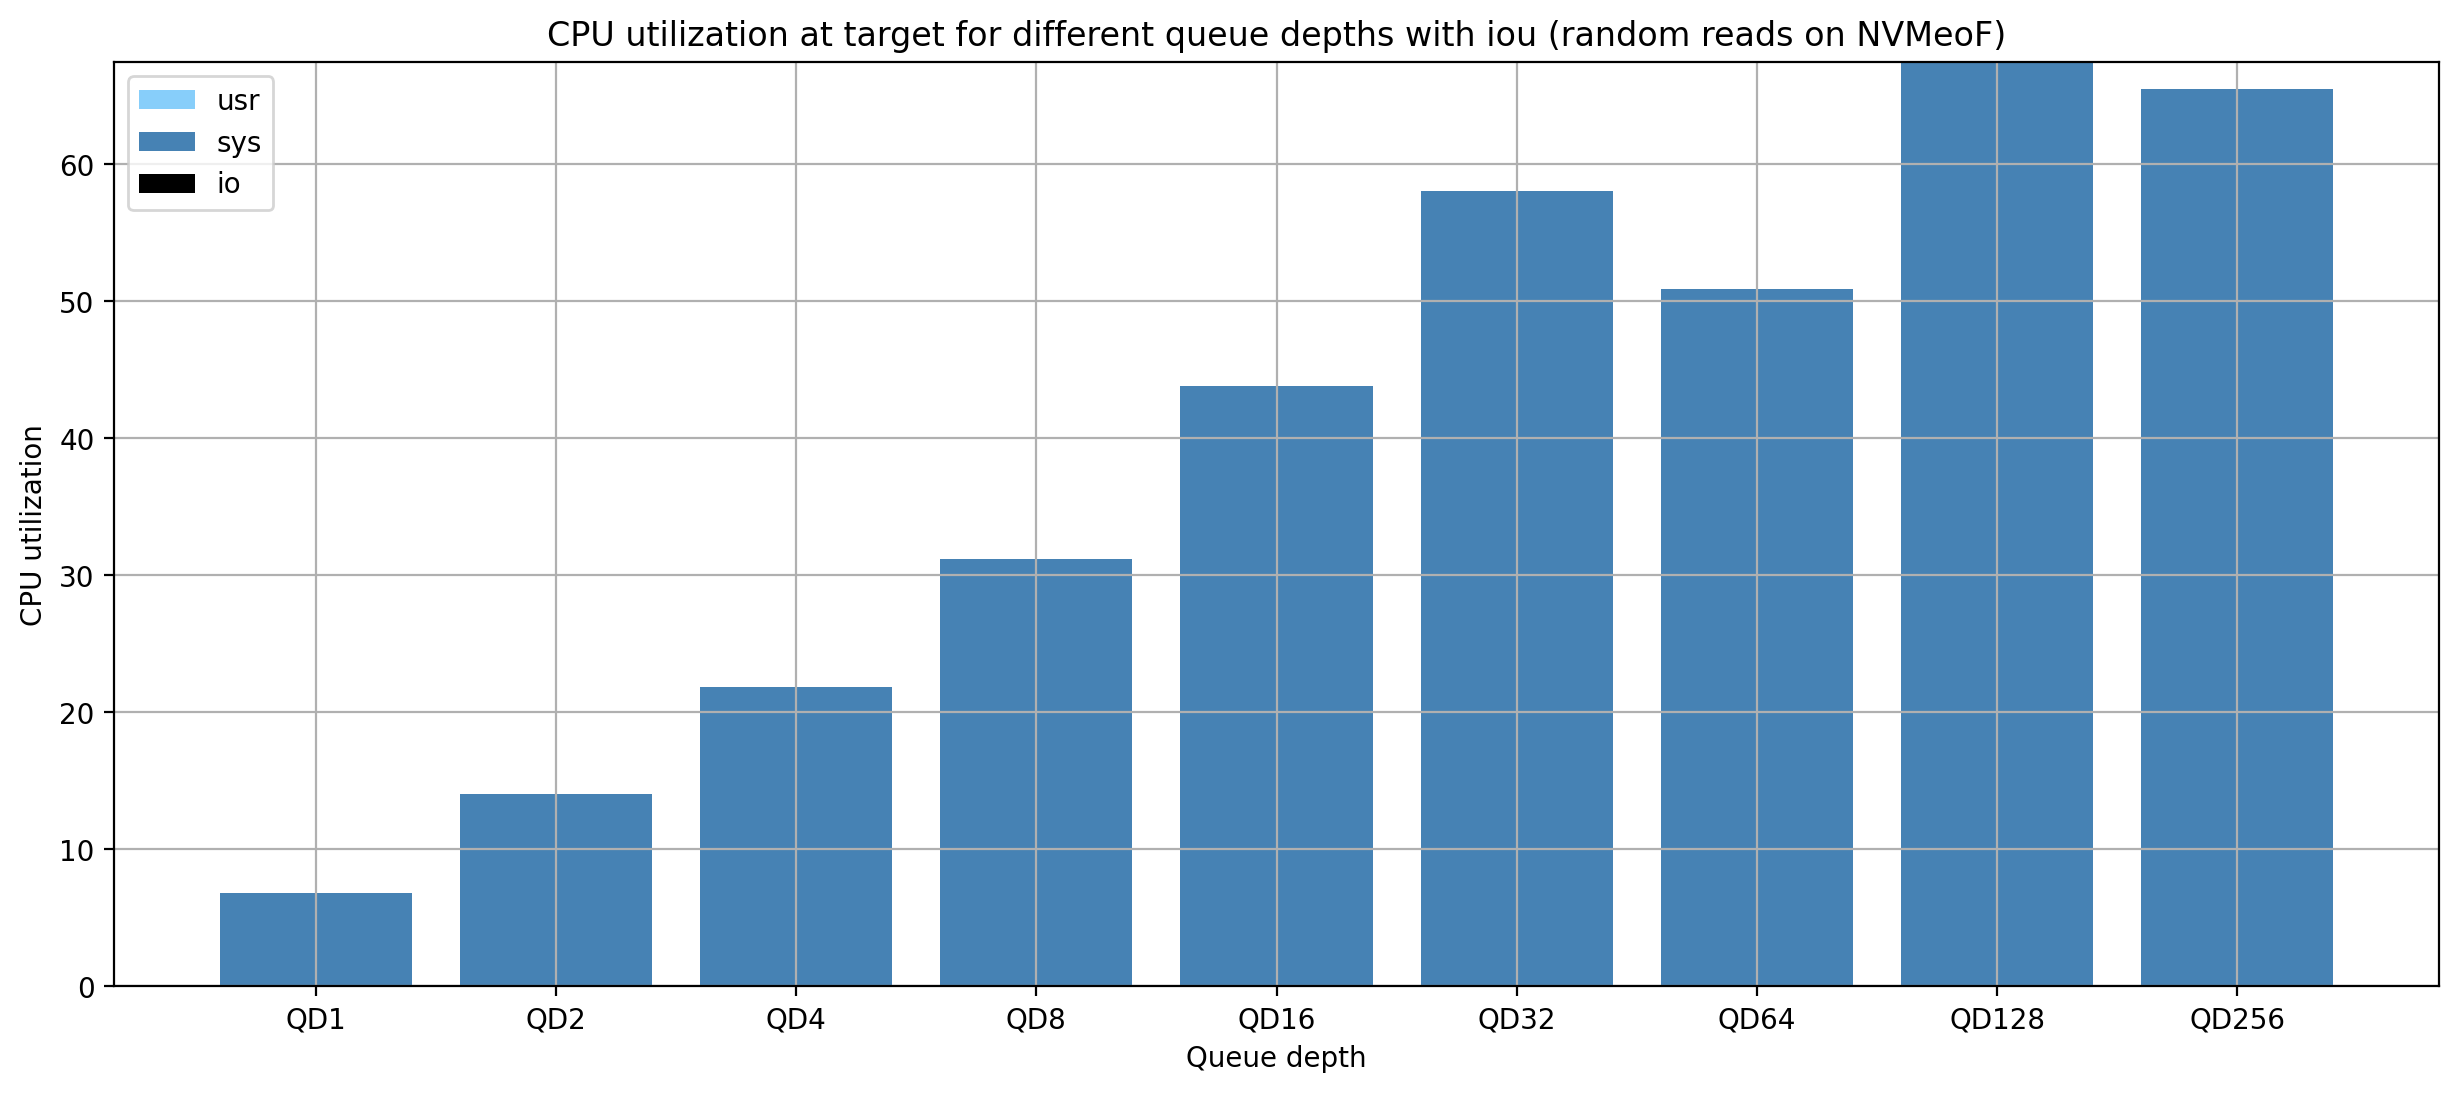

In [20]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    experiments = []
    for j in ["npoll_iou","poll_iou"]:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    cpu_target_utilization(experiments,"QD{}".format(i))
plt.title('CPU utilization at target for different queue depths with iou (random reads on NVMeoF)')
plt.xlabel("Queue depth")

"""
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
"""

remote_poll_ioup_SSD_randread_QD1_P1_4k {'all': {'usr': '0.00', 'sys': '0.69', 'io': '0.00'}, '0': {'usr': '0.00', 'sys': '0.04', 'io': '0.01'}, '1': {'usr': '0.00', 'sys': '0.02', 'io': '0.01'}, '2': {'usr': '0.01', 'sys': '0.02', 'io': '0.00'}, '3': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '4': {'usr': '0.00', 'sys': '0.02', 'io': '0.00'}, '5': {'usr': '0.00', 'sys': '7.62', 'io': '0.00'}, '6': {'usr': '0.01', 'sys': '0.01', 'io': '0.00'}, '7': {'usr': '0.00', 'sys': '0.02', 'io': '0.02'}, '8': {'usr': '0.01', 'sys': '0.04', 'io': '0.00'}, '9': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}}
remote_poll_ioup_SSD_randread_QD2_P1_4k {'all': {'usr': '0.00', 'sys': '1.22', 'io': '0.00'}, '0': {'usr': '0.00', 'sys': '0.02', 'io': '0.00'}, '1': {'usr': '0.00', 'sys': '0.01', 'io': '0.00'}, '2': {'usr': '0.01', 'sys': '0.02', 'io': '0.01'}, '3': {'usr': '0.00', 'sys': '0.01', 'io': '0.01'}, '4': {'usr': '0.00', 'sys': '0.00', 'io': '0.00'}, '5': {'usr': '0.00', 'sys': '14.54', 'io': '0.0

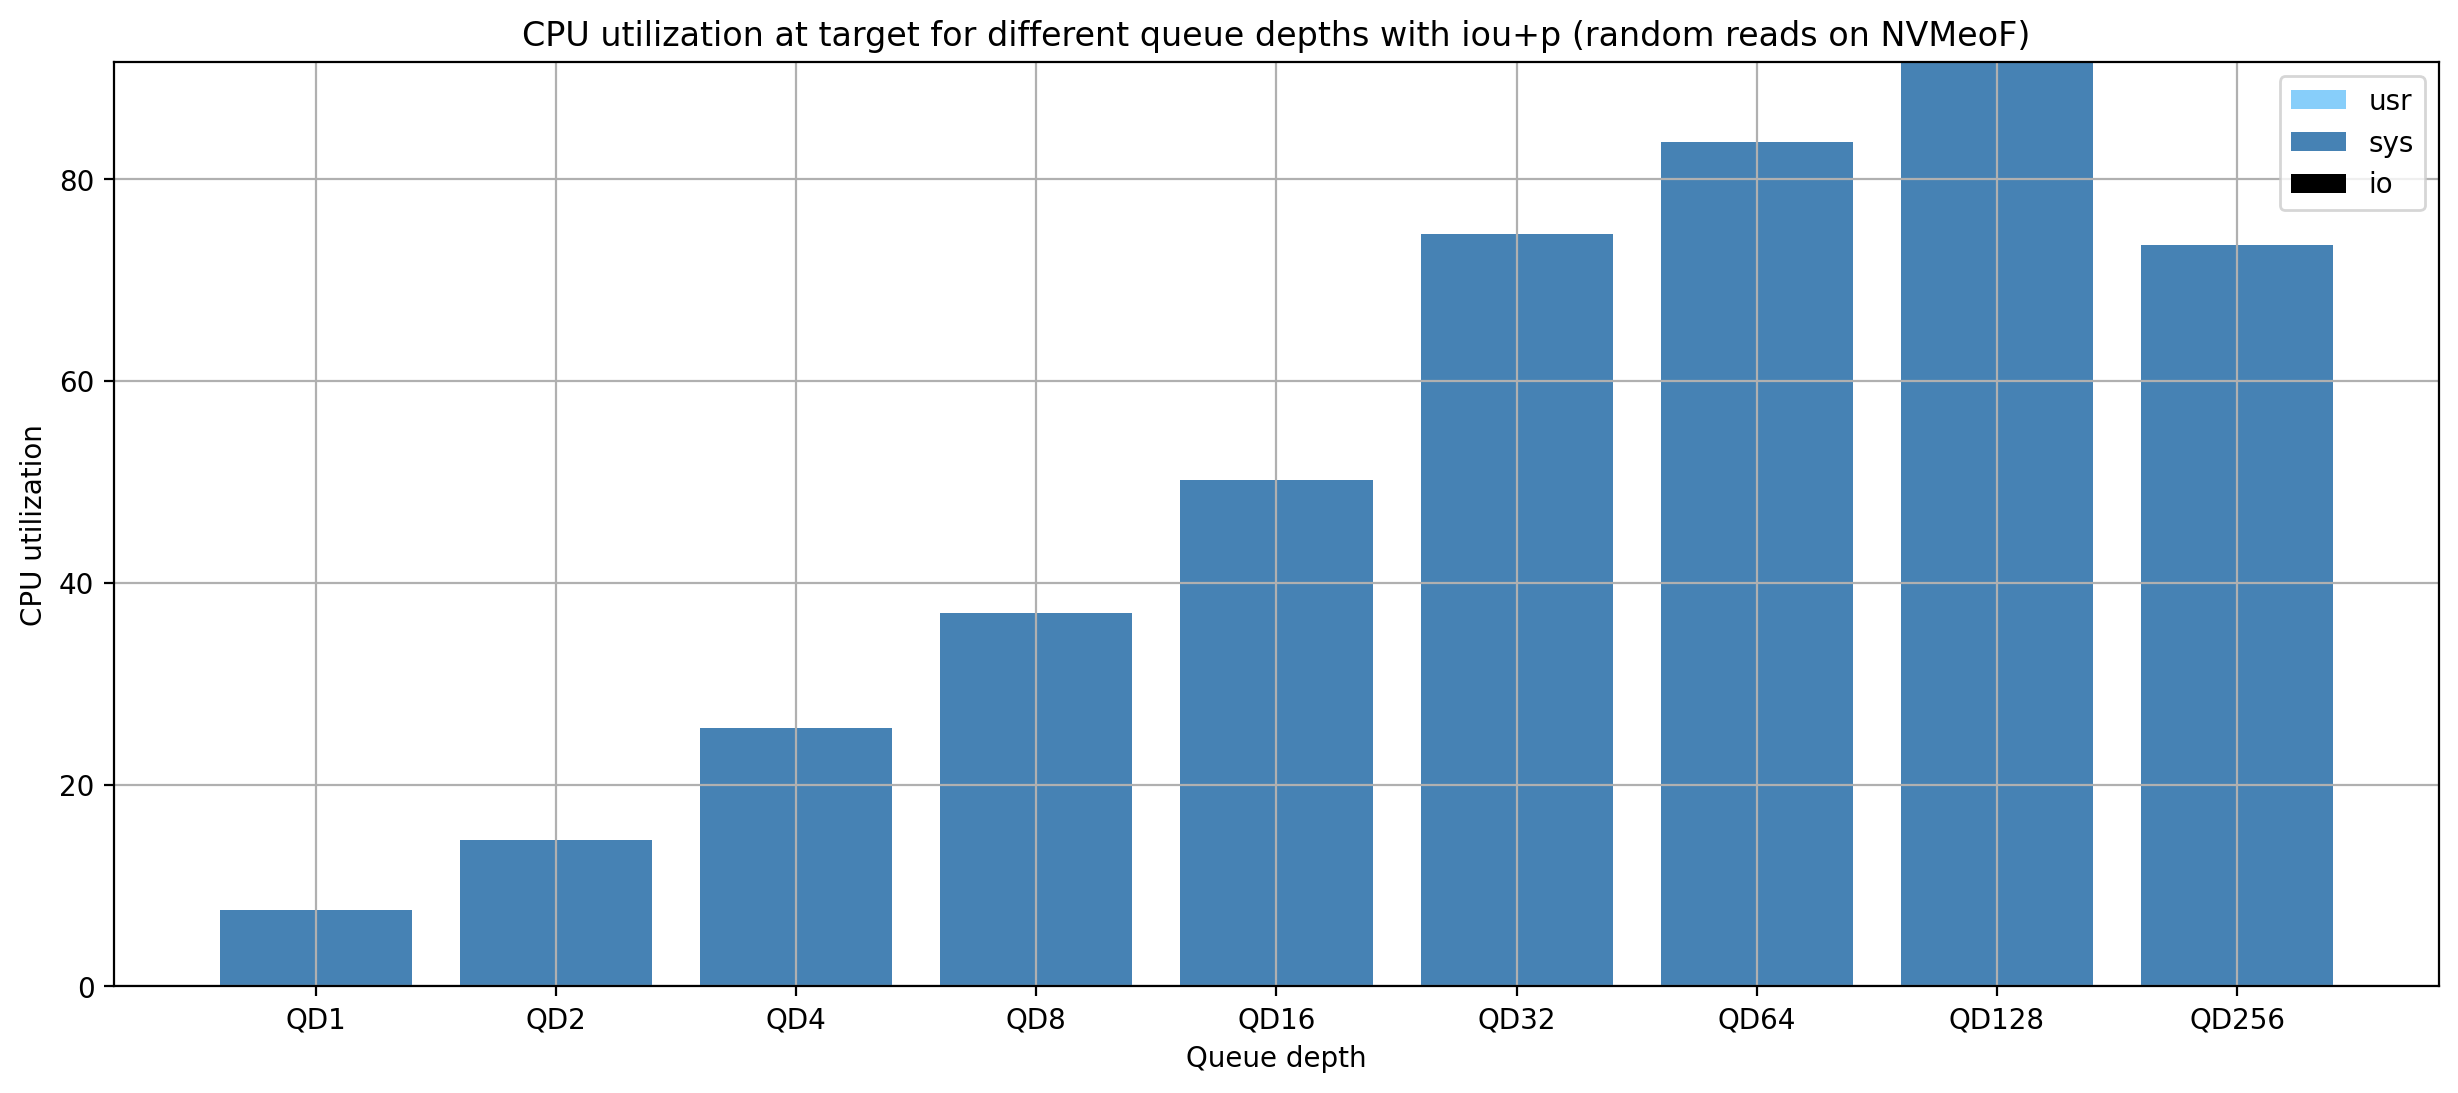

In [21]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_target_utilization("remote_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('CPU utilization at target for different queue depths with iou+p (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

remote_poll_iou+p_SSD_randread_QD1_P1_4k {'runtime': 120000, 'usr': 1.635, 'sys': 97.9375, 'ctx': 72205}
remote_poll_iou+p_SSD_randread_QD2_P1_4k {'runtime': 120000, 'usr': 2.7875, 'sys': 96.923333, 'ctx': 29559}
remote_poll_iou+p_SSD_randread_QD4_P1_4k {'runtime': 120000, 'usr': 3.8625, 'sys': 95.840833, 'ctx': 26997}
remote_poll_iou+p_SSD_randread_QD8_P1_4k {'runtime': 120000, 'usr': 4.791667, 'sys': 94.9275, 'ctx': 20484}
remote_poll_iou+p_SSD_randread_QD16_P1_4k {'runtime': 120000, 'usr': 7.143333, 'sys': 92.505, 'ctx': 28847}
remote_poll_iou+p_SSD_randread_QD32_P1_4k {'runtime': 120000, 'usr': 10.291667, 'sys': 89.135833, 'ctx': 57081}
remote_poll_iou+p_SSD_randread_QD64_P1_4k {'runtime': 120000, 'usr': 13.029167, 'sys': 85.596667, 'ctx': 144525}
remote_poll_iou+p_SSD_randread_QD128_P1_4k {'runtime': 120000, 'usr': 14.2775, 'sys': 77.2275, 'ctx': 289411}
remote_poll_iou+p_SSD_randread_QD256_P1_4k {'runtime': 120000, 'usr': 10.850833, 'sys': 44.491667, 'ctx': 2383166}


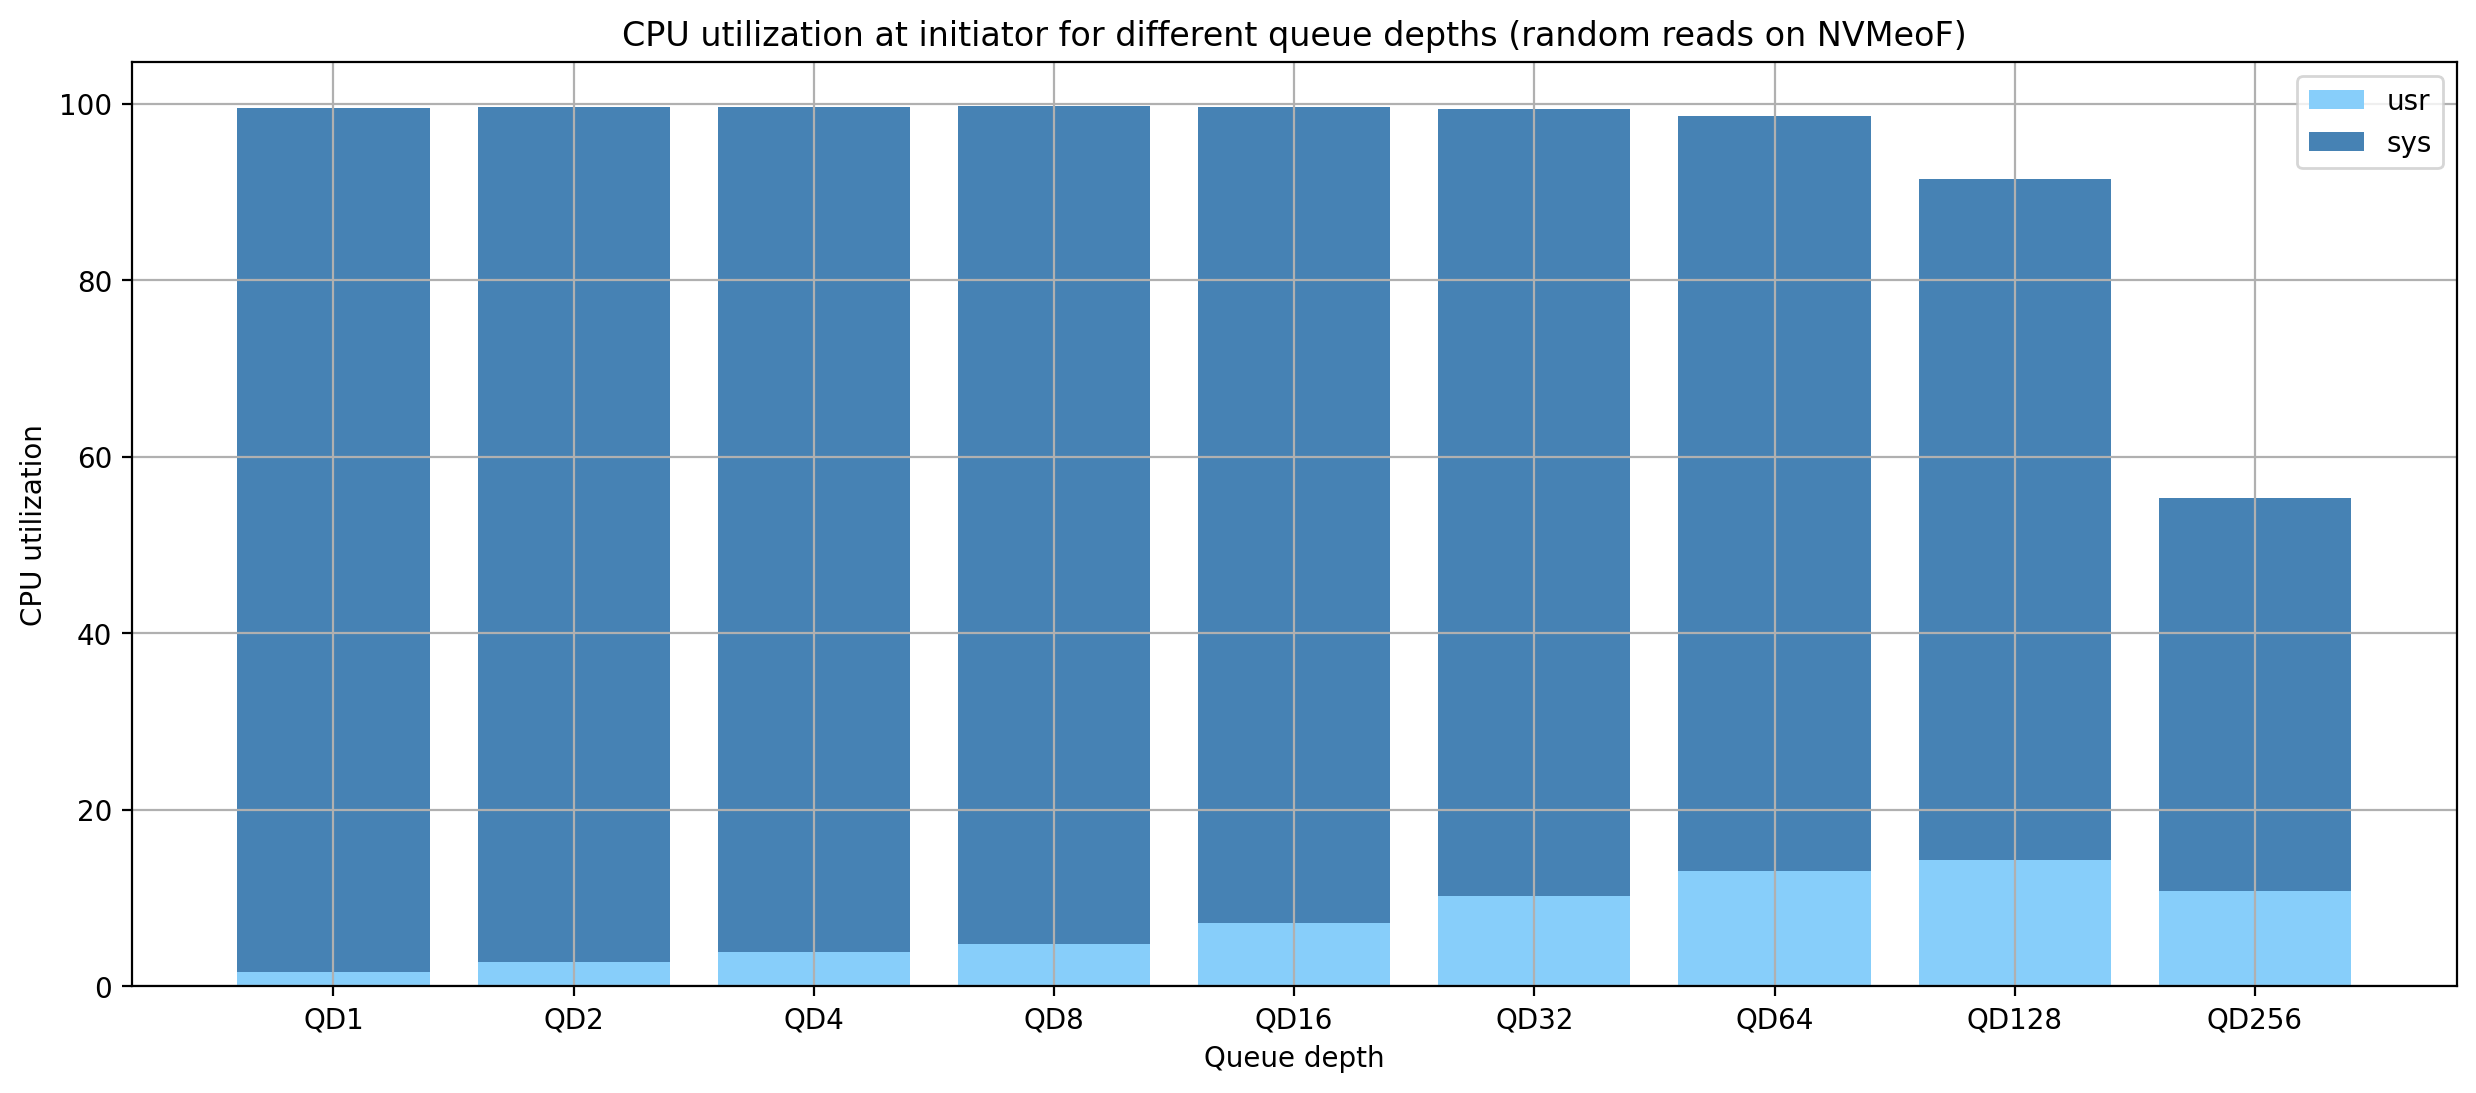

In [10]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in QD:
    cpu_utilization("remote_poll_iou+p_SSD_randread_QD{}_P1_4k".format(i),"QD{}".format(i))
plt.title('CPU utilization at initiator for different queue depths (random reads on NVMeoF)')
plt.xlabel("Queue depth")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
BAR_COLOR="springgreen"
fig, ax = plt.subplots(figsize=(25, 6), dpi=200)
for i in PROCESS:
    for j in QD:
        plot_iops_bar("local_SSD_randread_QD{}_P{}".format(j,i),"P{}.QD{}".format(i,j))
plt.title('IOPS bar graph for random read operation')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for j in PROCESS:
    experiments=[]
    for i in QD:
        experiments.append("local_SSD_randread_QD{}_P{}".format(i, j))
    plot_iops_line(experiments, QD, "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS vs number of processes (random read on local)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["npoll_iou","npoll_ioup"]:
    experiments=[]
    for i in PROCESS:
        experiments.append("remote_{}_SSD_randread_QD128_P{}_4k".format(j, i))
    plot_iops_line(experiments, PROCESS, "{}".format(j).split("_")[1])

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different number of cores with QD128 (random read on NVMeoF-TCP)')
plt.xlabel("Number of process")
plt.ylabel('KIOPS')
plt.legend()

npoll_iou [7.733141667, 13.803841667, 21.632045833, 32.466733333, 49.395166667, 69.748129707, 76.663807531, 105.478661088, 111.919364017]
npoll_ioup [7.9397041669999995, 14.344679167, 22.355879166999998, 33.133929167000005, 50.139566667, 76.81563333300001, 105.646333333, 118.358845188, 119.675468619]
poll_ioup [8.814447699, 15.130309622999999, 25.453393305000002, 38.644096233999996, 60.834493724, 98.977849372, 131.721108787, 148.165422594, 115.2723625]


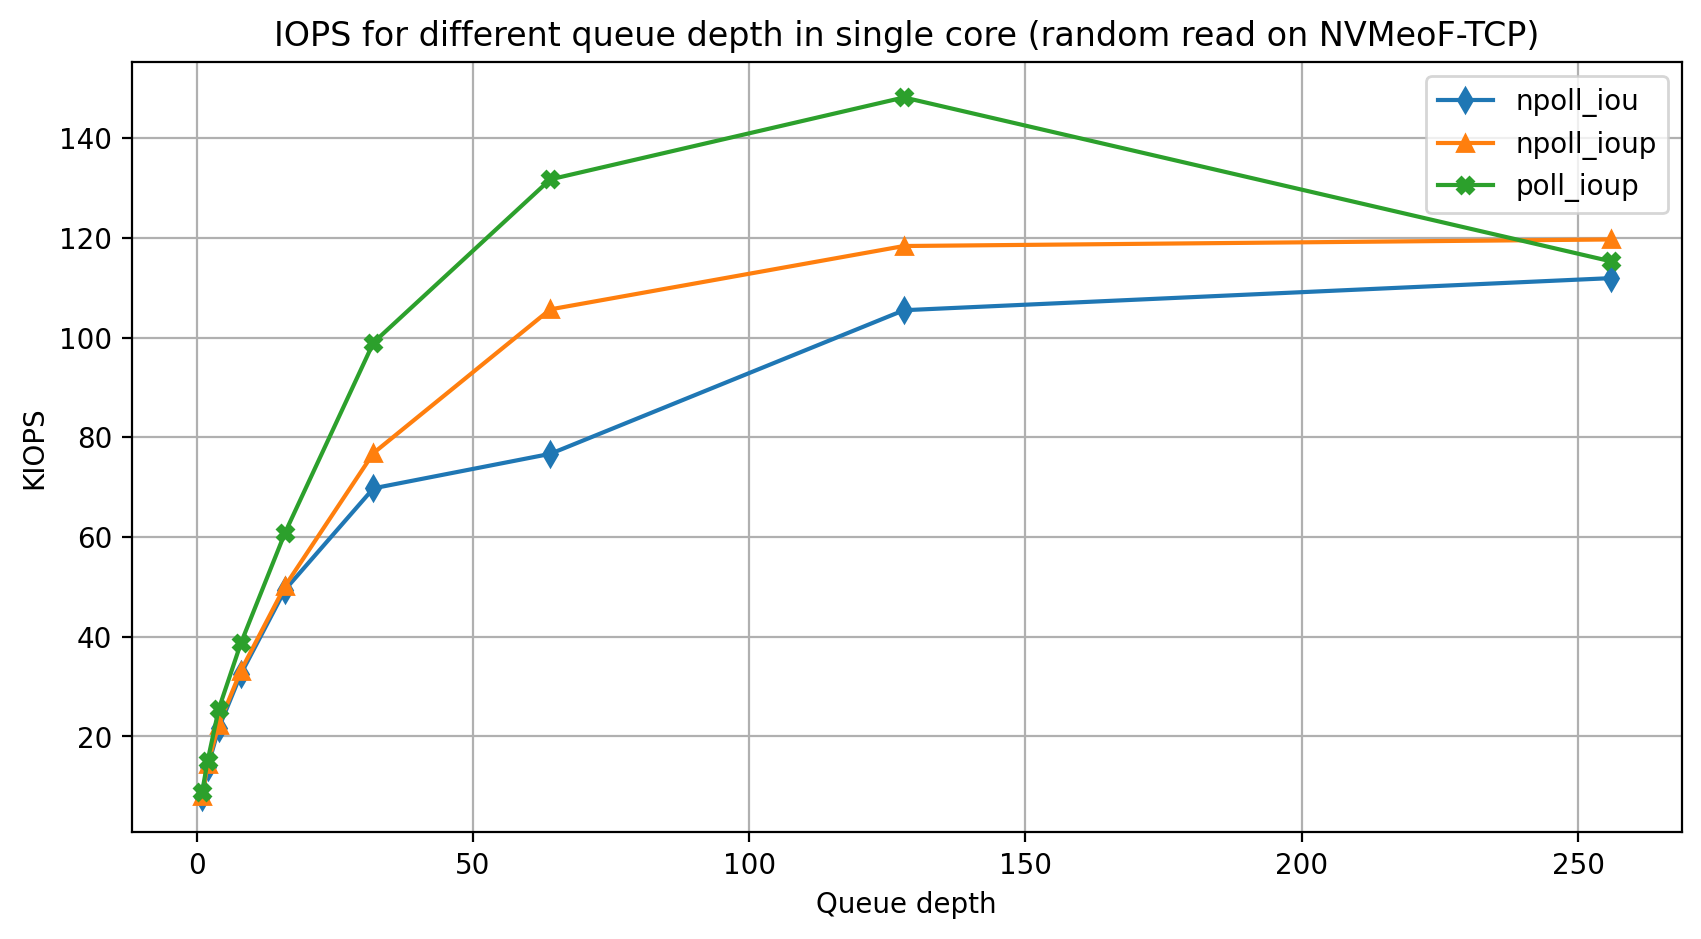

In [26]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["npoll_iou","npoll_ioup","poll_ioup"]:
    experiments=[]
    for i in QD:
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_iops_line(experiments, QD, "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different queue depth in single core (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

npoll_iou [7.4882416670000005, 21.370254167, 29.857841667, 31.802225941, 37.434966667, 40.638075, 42.933895833, 46.500987448, 54.644791667, 56.936683333, 59.1128, 60.329874477, 62.603716667, 63.592769874, 65.022266667, 65.846908333, 66.058414226, 66.1773, 65.688506276, 67.718430962, 67.72812133900001, 68.00630962299999, 65.1802125, 66.4256875, 64.89841249999999, 68.47522594099999, 67.230472803, 67.534966527, 66.426384937, 65.840870833, 64.237309623, 67.504857741, 86.84058159, 85.225297071, 84.717133333, 84.724075314, 85.287548117, 85.63130962299999, 84.364476987, 81.76093305399999, 82.205343096, 82.826309623, 87.52455416699999, 87.926481172, 88.62132636000001, 88.036439331, 85.899083682, 86.17498326399999, 87.770016736, 87.20792887, 84.737533333, 89.938924686, 89.577364017, 90.458970711, 88.44058159000001, 90.426870293, 91.32692887, 90.949631799, 88.936857741, 92.114694561, 91.417523013, 90.442284519, 91.86811250000001, 90.276774059]


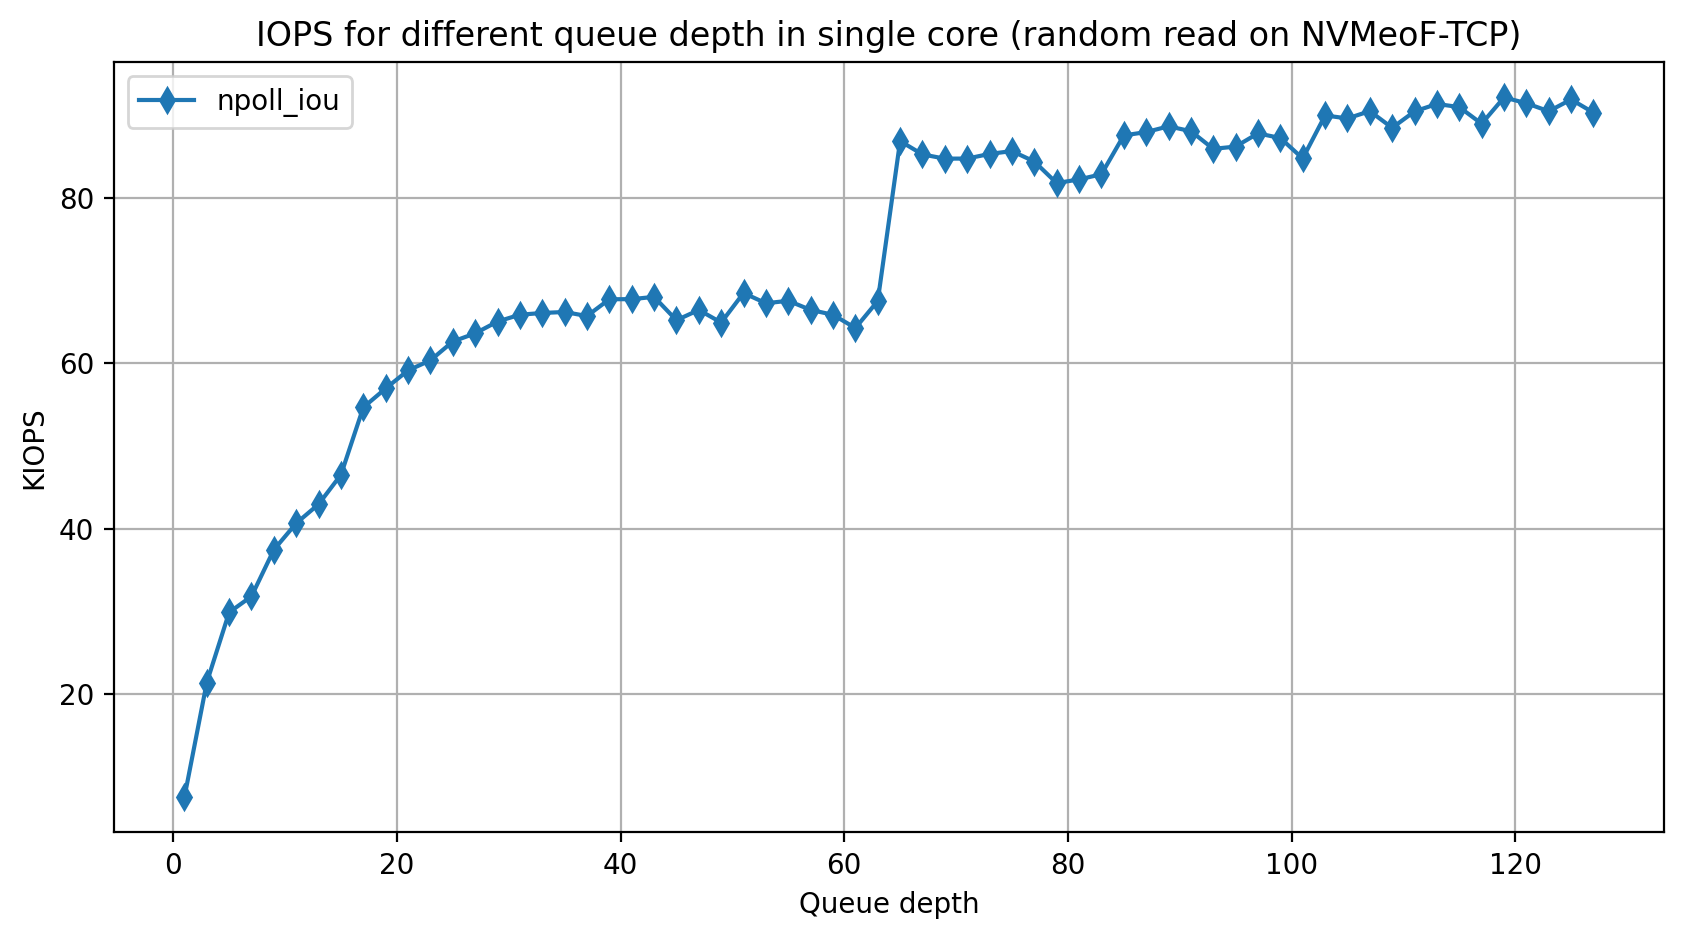

In [5]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
CALLS=0
for j in ["npoll_iou"]:
    experiments=[]
    for i in range(1,128,2):
        experiments.append("remote_{}_SSD_randread_QD{}_P1_4k".format(j, i))
    plot_iops_line(experiments, [i for i in range(1,128,2)], "{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS for different queue depth in single core (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
#plt.xticks([i for i in range(50,71)])
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

#IOPS
BAR_COLOR="springgreen"
for i in QD:
    plot_iops_bar("local_SSD_randread_QD{}_P1".format(i),"QD{}".format(i))
plt.xlabel("Queue depth")

#Latency
ax2 = ax.twinx()
for i in [50.0, 95.0, 99.99,"max"]:
    names = []
    experiments = []
    for j in QD:
        experiments.append("local_SSD_randread_QD{}_P1".format(j))
        names.append("QD{}".format(j))
    plot_lat_line(experiments, i, names)
    
plt.ylabel('Latency(' + u"\u03bc"+ 'S)')

plt.title("IOPS and latency vs queue depth 1P (random reads on local)")
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("local_SSD_randread_QD{}_P{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,50.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="P{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P50 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency (random read on local)")
plt.legend()

{'QD1': [122.368, 10.078033332999999], 'QD2': [144.384, 18.386808333], 'QD4': [216.064, 27.055775], 'QD8': [342.016, 35.222891667000006], 'QD16': [485.376, 53.788520833], 'QD32': [675.84, 81.1281], 'QD64': [1761.28, 64.757861925], 'QD128': [1515.52, 115.15873221800001], 'QD256': [2998.272, 116.48856903800001]}
{'QD1': [138.24, 18.613066946], 'QD2': [175.104, 31.336089557], 'QD4': [248.832, 47.9751], 'QD8': [358.4, 70.089710948], 'QD16': [509.952, 105.789686471], 'QD32': [700.416, 150.346740586], 'QD64': [1236.992, 185.839991667], 'QD128': [1597.44, 225.531648536], 'QD256': [3162.112, 219.45664016700002]}
{'QD1': [134.144, 36.716404167], 'QD2': [203.776, 57.3960625], 'QD4': [268.288, 89.264146165], 'QD8': [387.072, 133.930402354], 'QD16': [577.536, 197.07320852499998], 'QD32': [806.912, 288.224194369], 'QD64': [1269.76, 366.069857741], 'QD128': [1794.048, 403.59567364], 'QD256': [3981.312, 387.33874058600003]}
{'QD1': [177.152, 65.034263842], 'QD2': [264.192, 95.99952456400001], 'QD4': 

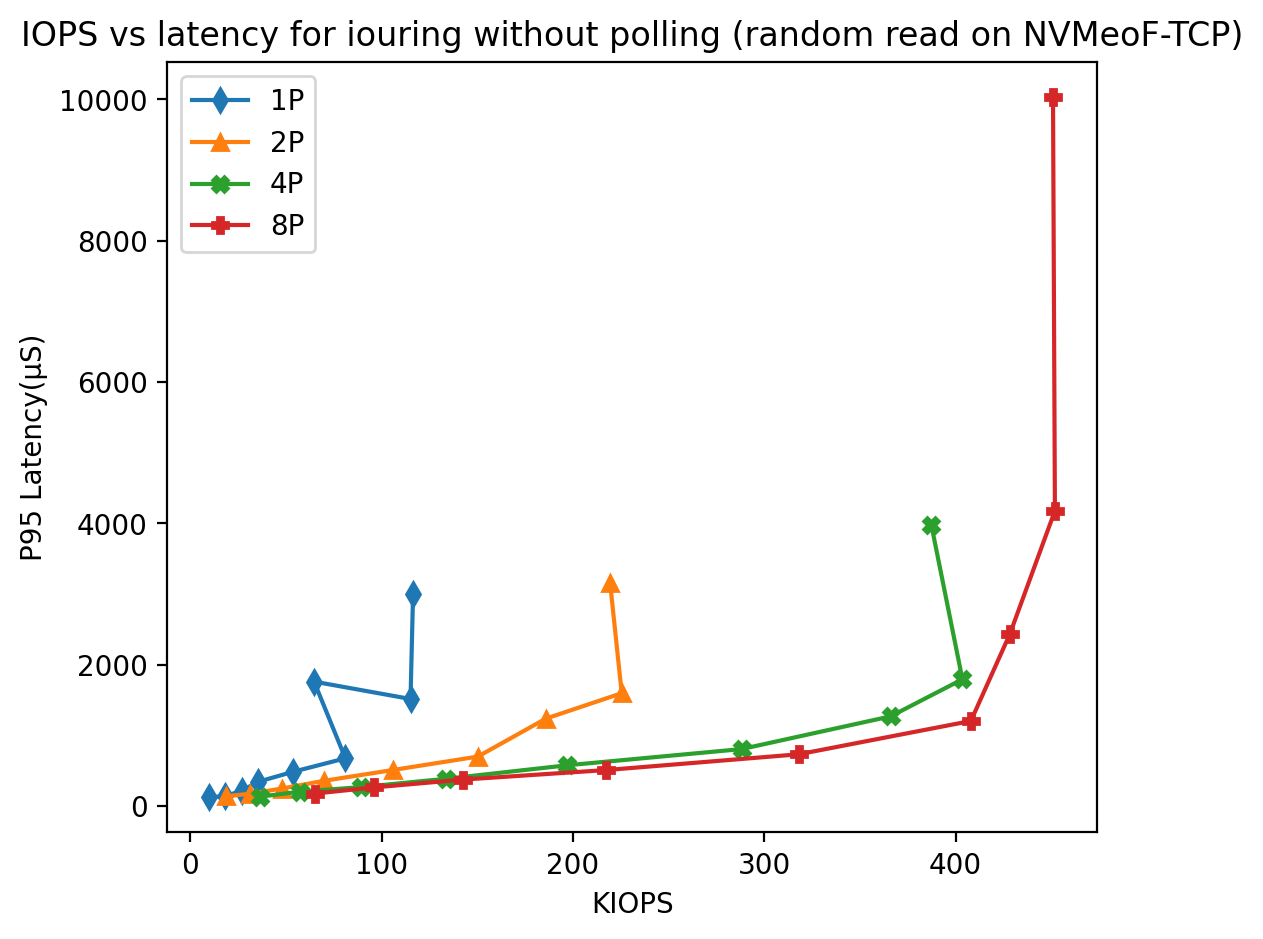

In [31]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("remote_npoll_iou_SSD_randread_QD{}_P{}_4k".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}P".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for iouring without polling (random read on NVMeoF-TCP)")
plt.legend()

{'QD1': [108.032, 11.748933053999998], 'QD2': [123.392, 21.595456067], 'QD4': [177.152, 31.119125522999997], 'QD8': [248.832, 41.551334728], 'QD16': [374.784, 66.319142259], 'QD32': [436.224, 102.528895397], 'QD64': [561.152, 135.124761506], 'QD128': [954.368, 147.75783263600002], 'QD256': [3096.576, 119.583305439]}
{'QD1': [113.152, 21.704443514999998], 'QD2': [134.144, 38.172271967], 'QD4': [197.632, 57.852748954], 'QD8': [288.768, 87.262322176], 'QD16': [411.648, 138.97841841000002], 'QD32': [509.952, 208.833121339], 'QD64': [643.072, 252.46457500000002], 'QD128': [1044.48, 269.249138075], 'QD256': [3358.72, 240.320468619]}
{'QD1': [116.224, 42.058719665], 'QD2': [152.576, 70.09442259400001], 'QD4': [216.064, 106.671656904], 'QD8': [321.536, 168.349539749], 'QD16': [493.568, 254.633384937], 'QD32': [692.224, 351.116384937], 'QD64': [921.6, 412.584502092], 'QD128': [1384.448, 449.435577406], 'QD256': [4882.432, 389.760778243]}
{'QD1': [132.096, 76.56934728], 'QD2': [195.584, 121.2345

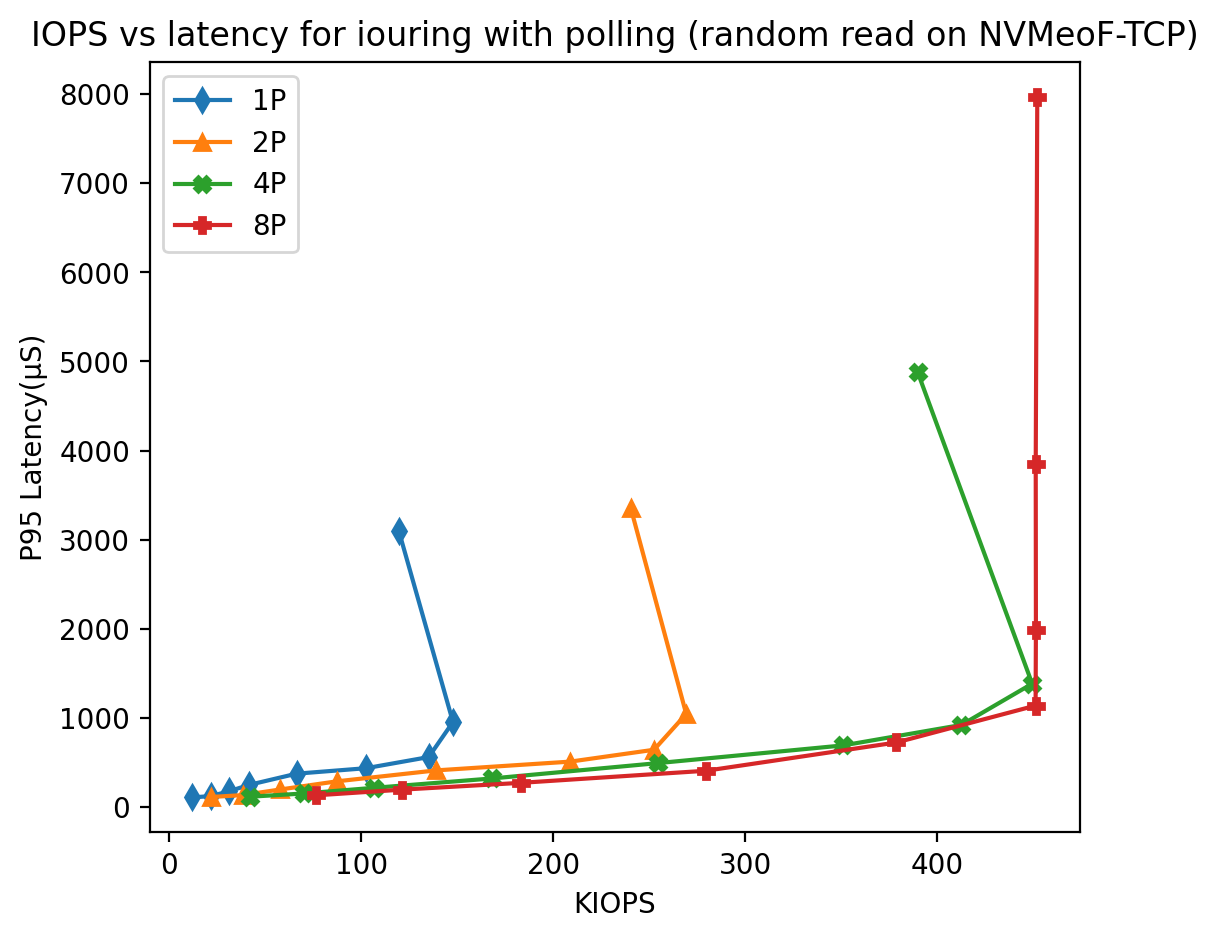

In [32]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("remote_poll_iou+p_SSD_randread_QD{}_P{}_4k".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}P".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for iouring with polling (random read on NVMeoF-TCP)")
plt.legend()

{'QD1': [105.984, 12.121046025], 'QD2': [121.344, 22.148338912], 'QD4': [171.008, 32.396020921], 'QD8': [244.736, 42.227941423], 'QD16': [370.688, 67.101251046], 'QD32': [456.704, 100.30184937199999], 'QD64': [536.576, 145.611598326], 'QD128': [774.144, 180.323661088], 'QD256': [3031.04, 120.378845833]}
{'QD1': [108.032, 11.748933053999998], 'QD2': [123.392, 21.595456067], 'QD4': [177.152, 31.119125522999997], 'QD8': [248.832, 41.551334728], 'QD16': [374.784, 66.319142259], 'QD32': [436.224, 102.528895397], 'QD64': [561.152, 135.124761506], 'QD128': [954.368, 147.75783263600002], 'QD256': [3096.576, 119.583305439]}
{'QD1': [121.344, 8.526799163], 'QD2': [138.24, 16.562439331], 'QD4': [207.872, 26.041569038000002], 'QD8': [309.248, 37.338271967], 'QD16': [436.224, 58.124937238], 'QD32': [561.152, 84.553079498], 'QD64': [749.568, 112.886665272], 'QD128': [1400.832, 118.824012552], 'QD256': [3227.648, 104.15758577400001]}
{'QD1': [193.536, 6.43441841], 'QD2': [207.872, 12.190958159], 'QD4

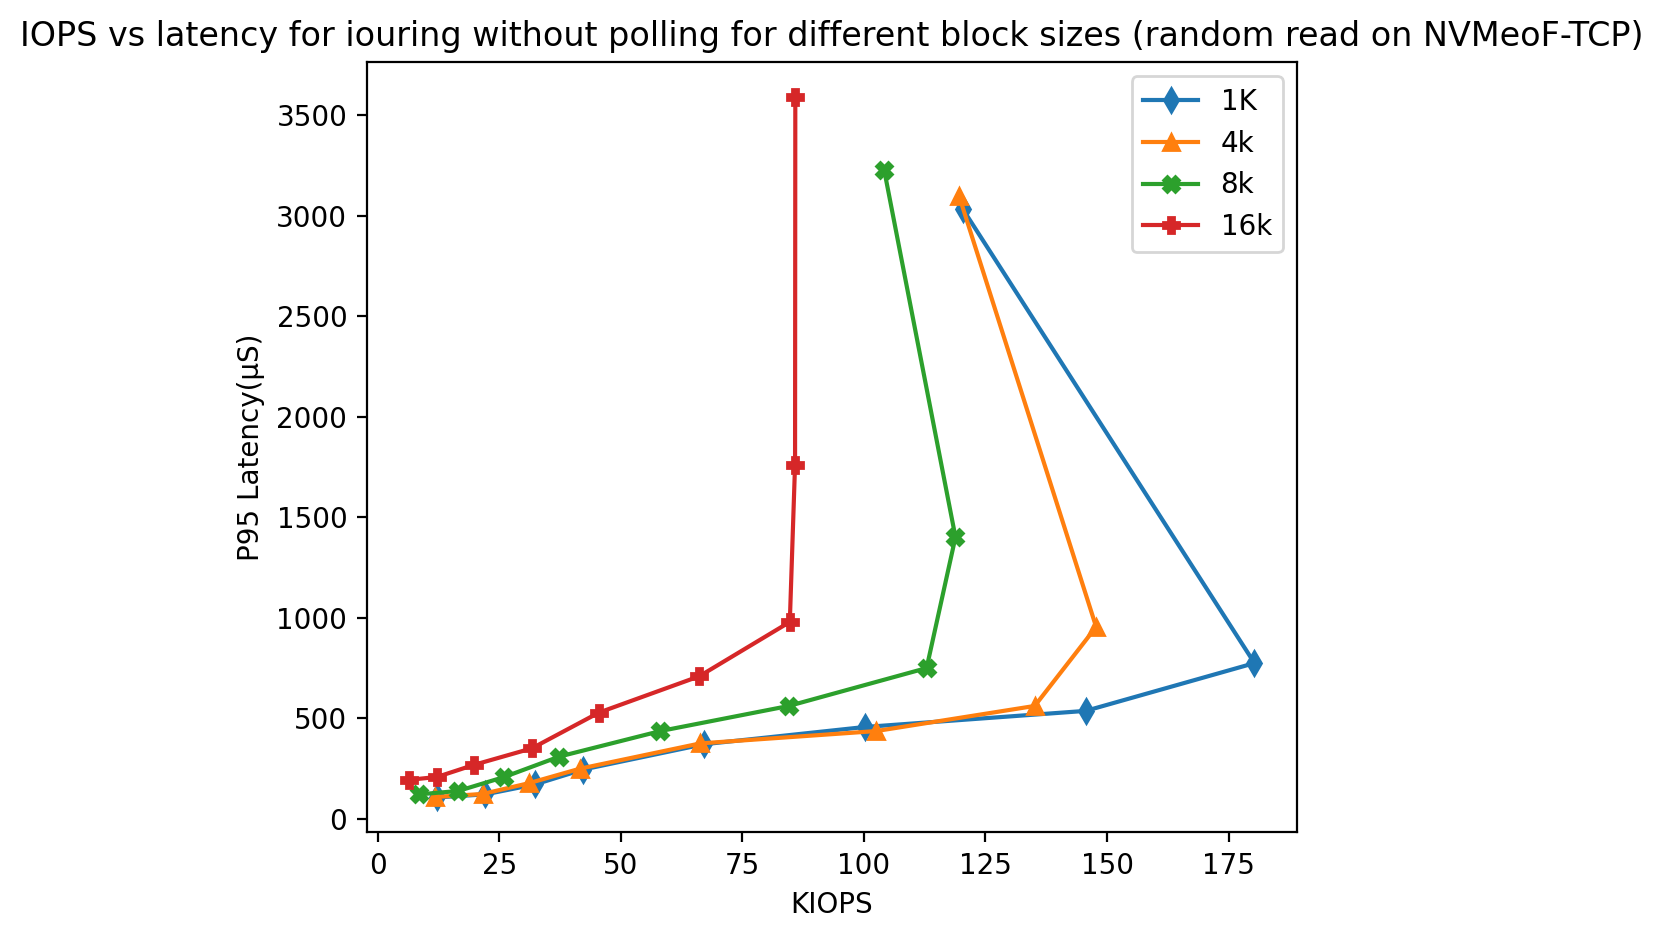

In [40]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
CALLS=0
scatter_label = {}
for i in ["1K","4k","8k","16k"]:
    names = []
    experiments = []
    for j in QD:
        experiments.append("remote_poll_iou+p_SSD_randread_QD{}_P1_{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,95.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P95 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency for iouring without polling for different block sizes (random read on NVMeoF-TCP)")
plt.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
for i in PROCESS:
    cpu_utilization("local_SSD_randread_QD32_P{}".format(i),"P{}".format(i))
plt.title('CPU utilization vs queue depths')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

In [ ]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0
for j in PROCESS:
    CALLS=0
    for i in [1]:
        plot_lat_percentile("local_SSD_randread_QD{}_P{}".format(i,j),"QD{}".format(i),0,1000, ax[pos[index][0], pos[index][1]])
    ax[pos[index][0], pos[index][1]].set_title("{} Fio process".format(j))
    index += 1

ax[0,0].legend()

#plt.title("ECDF latency distribution for diff fio process (random reads on local)")
fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(-0.01, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('Latency percentile for N fio process with different QD (rand read local)', fontsize=16)
plt.tight_layout()

remote_npoll_iou_SSD_randread_QD1_P1_4k {1.0: 87552.0, 5.0: 89600.0, 10.0: 90624.0, 20.0: 91648.0, 30.0: 92672.0, 40.0: 99840.0, 50.0: 138240.0, 60.0: 140288.0, 70.0: 140288.0, 80.0: 142336.0, 90.0: 156672.0, 95.0: 156672.0, 99.0: 162816.0, 99.5: 173056.0, 99.9: 197632.0, 99.95: 220160.0, 99.99: 296960.0}
remote_poll_ioup_SSD_randread_QD1_P1_4k {1.0: 70144.0, 5.0: 72192.0, 10.0: 72192.0, 20.0: 73216.0, 30.0: 73216.0, 40.0: 77312.0, 50.0: 121344.0, 60.0: 122368.0, 70.0: 122368.0, 80.0: 128512.0, 90.0: 138240.0, 95.0: 140288.0, 99.0: 142336.0, 99.5: 144384.0, 99.9: 154624.0, 99.95: 160768.0, 99.99: 203776.0}
remote_npoll_ioup_SSD_randread_QD1_P1_4k {1.0: 86528.0, 5.0: 91648.0, 10.0: 91648.0, 20.0: 92672.0, 30.0: 92672.0, 40.0: 94720.0, 50.0: 125440.0, 60.0: 140288.0, 70.0: 142336.0, 80.0: 142336.0, 90.0: 142336.0, 95.0: 156672.0, 99.0: 158720.0, 99.5: 168960.0, 99.9: 193536.0, 99.95: 214016.0, 99.99: 346112.0}
remote_npoll_iou_SSD_randread_QD32_P1_4k {1.0: 191488.0, 5.0: 228352.0, 10.0: 

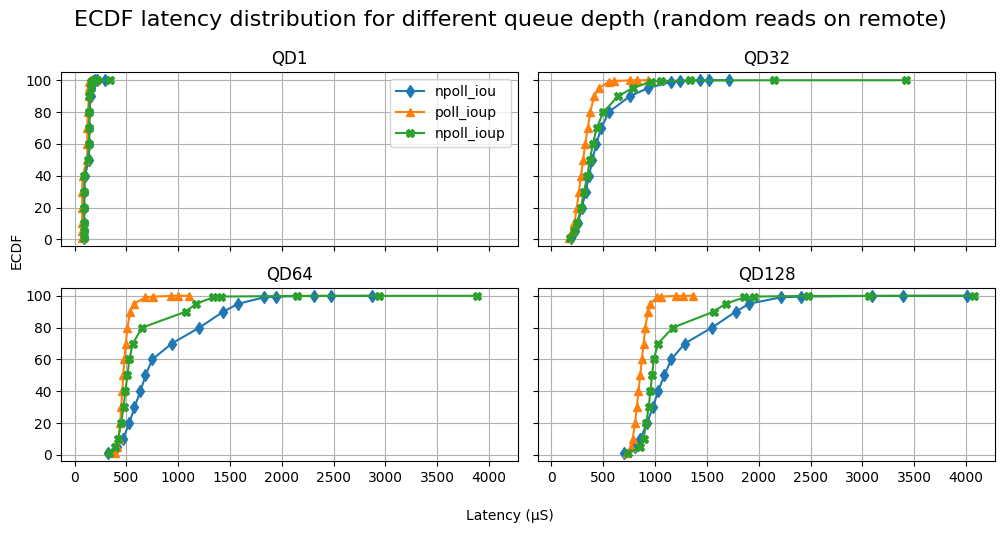

In [30]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,5))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0

for i in [1, 32, 64, 128]:
    CALLS=0
    plot_lat_percentile("remote_npoll_iou_SSD_randread_QD{}_P1_4k".format(i),"npoll_iou",0,1000, ax[pos[index][0], pos[index][1]])
    plot_lat_percentile("remote_poll_ioup_SSD_randread_QD{}_P1_4k".format(i),"poll_ioup",0,1000, ax[pos[index][0], pos[index][1]])
    plot_lat_percentile("remote_npoll_ioup_SSD_randread_QD{}_P1_4k".format(i),"npoll_ioup",0,1000, ax[pos[index][0], pos[index][1]])

    ax[pos[index][0], pos[index][1]].set_title("QD{}".format(i))
    index += 1

ax[pos[0][0], pos[0][1]].legend()

fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(0, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('ECDF latency distribution for different queue depth (random reads on remote)', fontsize=16)

plt.tight_layout()

remote_poll_iou_SSD_randread_QD1_P1_4k {1.0: 87552.0, 5.0: 90624.0, 10.0: 90624.0, 20.0: 91648.0, 30.0: 92672.0, 40.0: 94720.0, 50.0: 138240.0, 60.0: 140288.0, 70.0: 140288.0, 80.0: 142336.0, 90.0: 142336.0, 95.0: 150528.0, 99.0: 158720.0, 99.5: 173056.0, 99.9: 203776.0, 99.95: 216064.0, 99.99: 325632.0}
remote_poll_ioup_SSD_randread_QD1_P1_4k {1.0: 70144.0, 5.0: 72192.0, 10.0: 72192.0, 20.0: 73216.0, 30.0: 73216.0, 40.0: 77312.0, 50.0: 121344.0, 60.0: 122368.0, 70.0: 122368.0, 80.0: 128512.0, 90.0: 138240.0, 95.0: 140288.0, 99.0: 142336.0, 99.5: 144384.0, 99.9: 154624.0, 99.95: 160768.0, 99.99: 203776.0}
remote_npoll_ioup_SSD_randread_QD1_P1_4k {1.0: 86528.0, 5.0: 91648.0, 10.0: 91648.0, 20.0: 92672.0, 30.0: 92672.0, 40.0: 94720.0, 50.0: 125440.0, 60.0: 140288.0, 70.0: 142336.0, 80.0: 142336.0, 90.0: 142336.0, 95.0: 156672.0, 99.0: 158720.0, 99.5: 168960.0, 99.9: 193536.0, 99.95: 214016.0, 99.99: 346112.0}


Text(0.5, 1.0, 'ECDF latency plot for QD1 (random read on NVMeoF-TCP)')

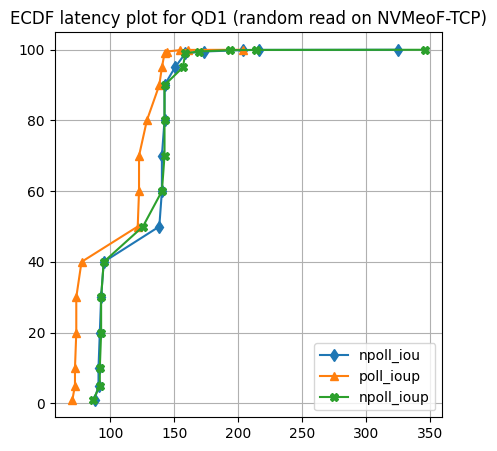

In [31]:
fig, ax = plt.subplots(figsize=(5,5))
CALLS=0
plot_lat_percentile("remote_poll_iou_SSD_randread_QD1_P1_4k".format(i),"npoll_iou",0,1000, ax)
plot_lat_percentile("remote_poll_ioup_SSD_randread_QD1_P1_4k".format(i),"poll_ioup",0,1000, ax)
plot_lat_percentile("remote_npoll_ioup_SSD_randread_QD1_P1_4k".format(i),"npoll_ioup",0,1000, ax)
plt.legend()
plt.title("ECDF latency plot for QD1 (random read on NVMeoF-TCP)")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for j in PROCESS:
    experiments=[]
    for i in QD:
        experiments.append("local_compute_SSD_randread_QD{}_BP{}".format(i, j))
    plot_iops_line(experiments, QD, "BP{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS vs queue depth compute interference (random read on local)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

local_compute_SSD_randread_QD1_BP1 {1.0: 23680.0, 5.0: 23680.0, 10.0: 23936.0, 20.0: 23936.0, 30.0: 24192.0, 40.0: 24192.0, 50.0: 24448.0, 60.0: 24704.0, 70.0: 69120.0, 80.0: 69120.0, 90.0: 81408.0, 95.0: 81408.0, 99.0: 3031040.0, 99.5: 4014080.0, 99.9: 5013504.0, 99.95: 5079040.0, 99.99: 6258688.0}
local_compute_SSD_randread_QD1_BP2 {1.0: 23680.0, 5.0: 23680.0, 10.0: 23936.0, 20.0: 23936.0, 30.0: 24192.0, 40.0: 24192.0, 50.0: 24192.0, 60.0: 24448.0, 70.0: 69120.0, 80.0: 69120.0, 90.0: 81408.0, 95.0: 81408.0, 99.0: 4046848.0, 99.5: 7045120.0, 99.9: 8978432.0, 99.95: 10027008.0, 99.99: 11993088.0}
local_compute_SSD_randread_QD1_BP4 {1.0: 23680.0, 5.0: 23680.0, 10.0: 23936.0, 20.0: 23936.0, 30.0: 24192.0, 40.0: 24192.0, 50.0: 24192.0, 60.0: 24448.0, 70.0: 69120.0, 80.0: 69120.0, 90.0: 81408.0, 95.0: 81408.0, 99.0: 10813440.0, 99.5: 14090240.0, 99.9: 16187392.0, 99.95: 17956864.0, 99.99: 20054016.0}
local_compute_SSD_randread_QD1_BP8 {1.0: 23680.0, 5.0: 23680.0, 10.0: 23936.0, 20.0: 23936

Text(0.5, 1.0, 'Latency ECDF with compute interference (rand read on local)')

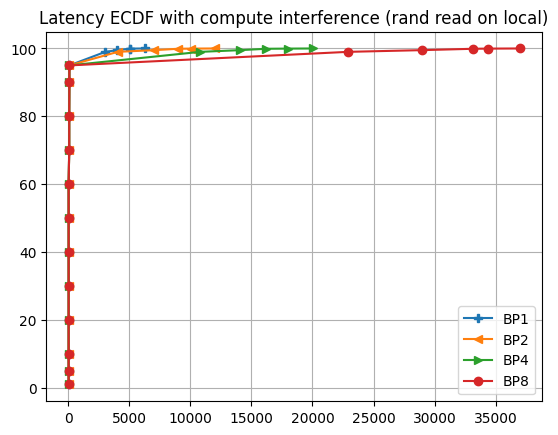

In [34]:
for j in PROCESS:
    plot_lat_percentile("local_compute_SSD_randread_QD1_BP{}".format(j),"BP{}".format(j),0,1000)
plt.legend()
plt.title("Latency ECDF with compute interference (rand read on local)")

In [ ]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0
for j in PROCESS:
    CALLS=0
    for i in [1]:
        plot_lat_percentile("local_compute_SSD_randread_QD{}_BP{}".format(i,j),"QD{}".format(i),0,1000, ax[pos[index][0], pos[index][1]])
    ax[pos[index][0], pos[index][1]].set_title("{} background process".format(j))
    index += 1

ax[0,0].legend()

#plt.title("ECDF latency distribution for diff fio process (random reads on local)")
fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(-0.01, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('Latency percentile for N compute interference with different QD (rand read local)', fontsize=16)
plt.tight_layout()

{'QD1': [24.448, 11.462647059], 'QD2': [70.144, 13.99502521], 'QD4': [91.648, 20.345975], 'QD8': [109.056, 34.203302521], 'QD16': [97.792, 68.674193277], 'QD32': [122.368, 115.538], 'QD64': [164.864, 165.710117647], 'QD128': [337.92, 185.761554622], 'QD256': [782.336, 166.039445378]}
{'QD1': [24.192, 7.742840336], 'QD2': [69.12, 10.437621849], 'QD4': [103.936, 13.489689076000001], 'QD8': [117.248, 21.138697478999998], 'QD16': [125.44, 40.603512605000006], 'QD32': [122.368, 80.263151261], 'QD64': [160.768, 114.227], 'QD128': [378.88, 111.76020833300001], 'QD256': [774.144, 112.10922689099999]}
{'QD1': [24.192, 4.605647059], 'QD2': [69.12, 6.218806722999999], 'QD4': [104.96, 7.957084034], 'QD8': [154.624, 10.476], 'QD16': [134.144, 20.755016807], 'QD32': [138.24, 42.449478991999996], 'QD64': [162.816, 69.821226891], 'QD128': [382.976, 66.999605042], 'QD256': [749.568, 69.73743697500001]}
{'QD1': [24.448, 2.511478992], 'QD2': [69.12, 3.430966387], 'QD4': [104.96, 4.395386555], 'QD8': [154

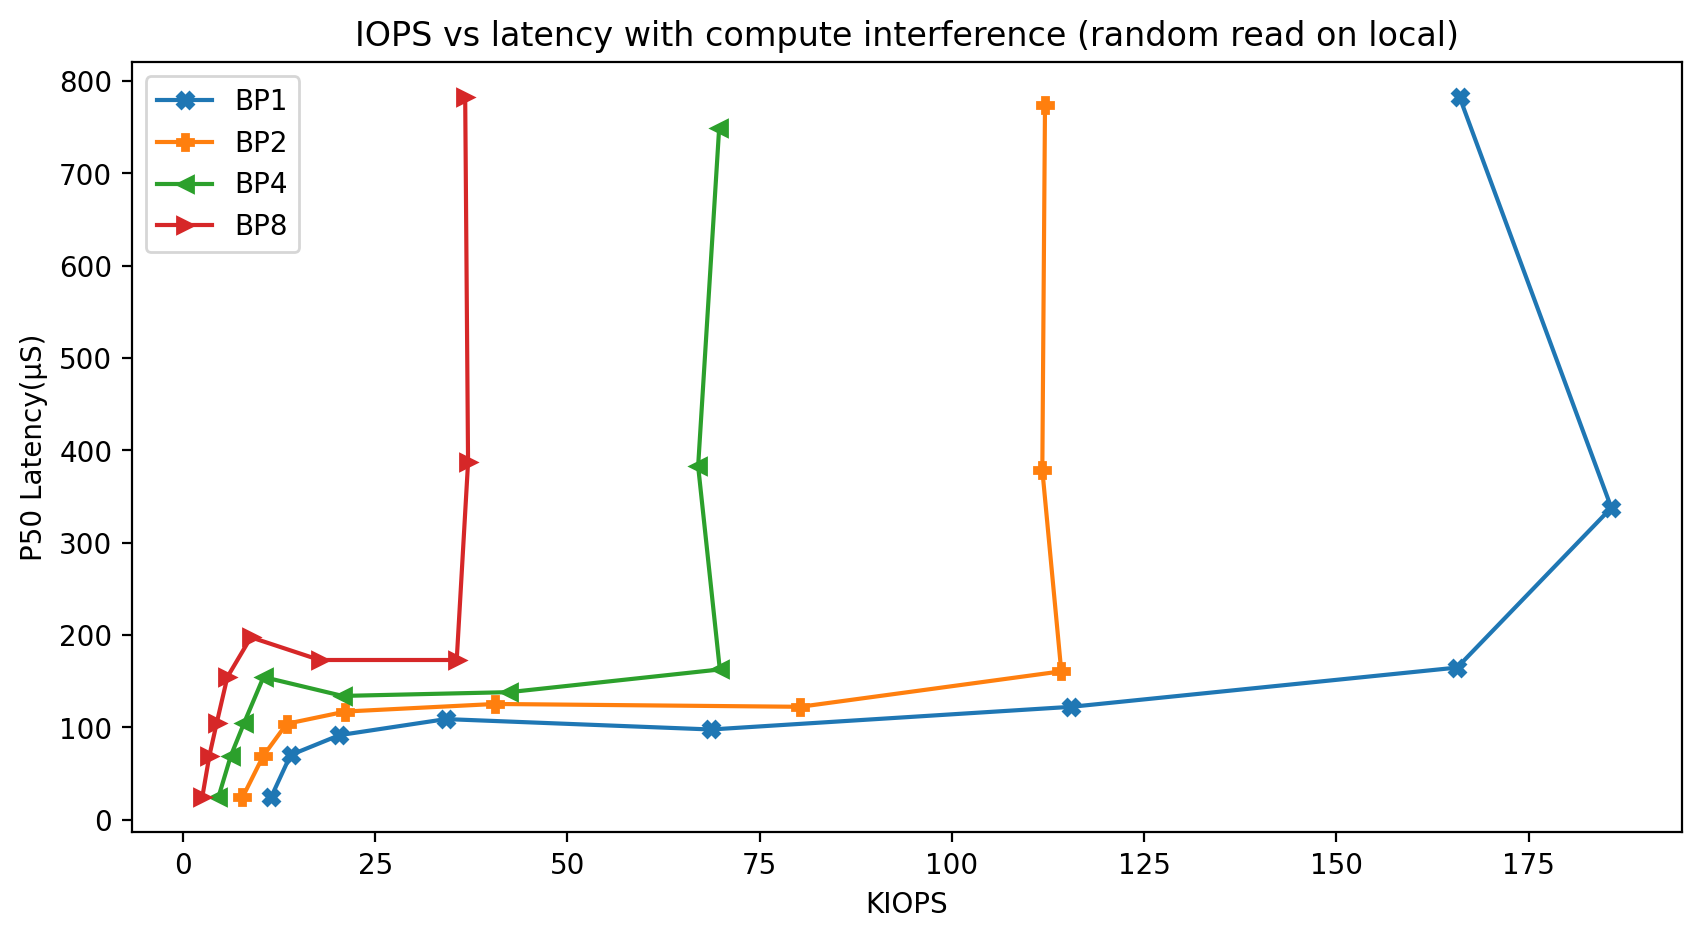

In [21]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("local_compute_SSD_randread_QD{}_BP{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,50.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="BP{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P50 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency with compute interference (random read on local)")
plt.legend()

BP1 [4.341361345, 6.819722689, 11.040848739, 17.814537815, 26.410084034, 33.132722689000005, 40.180596639, 53.411184874, 51.734226891]
BP2 [2.731319328, 4.931907562999999, 7.462815126000001, 11.923084034, 17.741462185, 22.880831933, 28.897151260999998, 36.441705882, 35.929764706]
BP4 [1.469243697, 2.731117647, 4.268873950000001, 6.992764706, 10.941798319, 14.042966387, 17.78107563, 23.181966387, 22.823907563000002]
BP8 [0.79789916, 1.423058824, 2.438218487, 3.868907563, 5.7071176470000005, 7.935722689, 9.871705882, 12.077327730999999, 12.093529412]


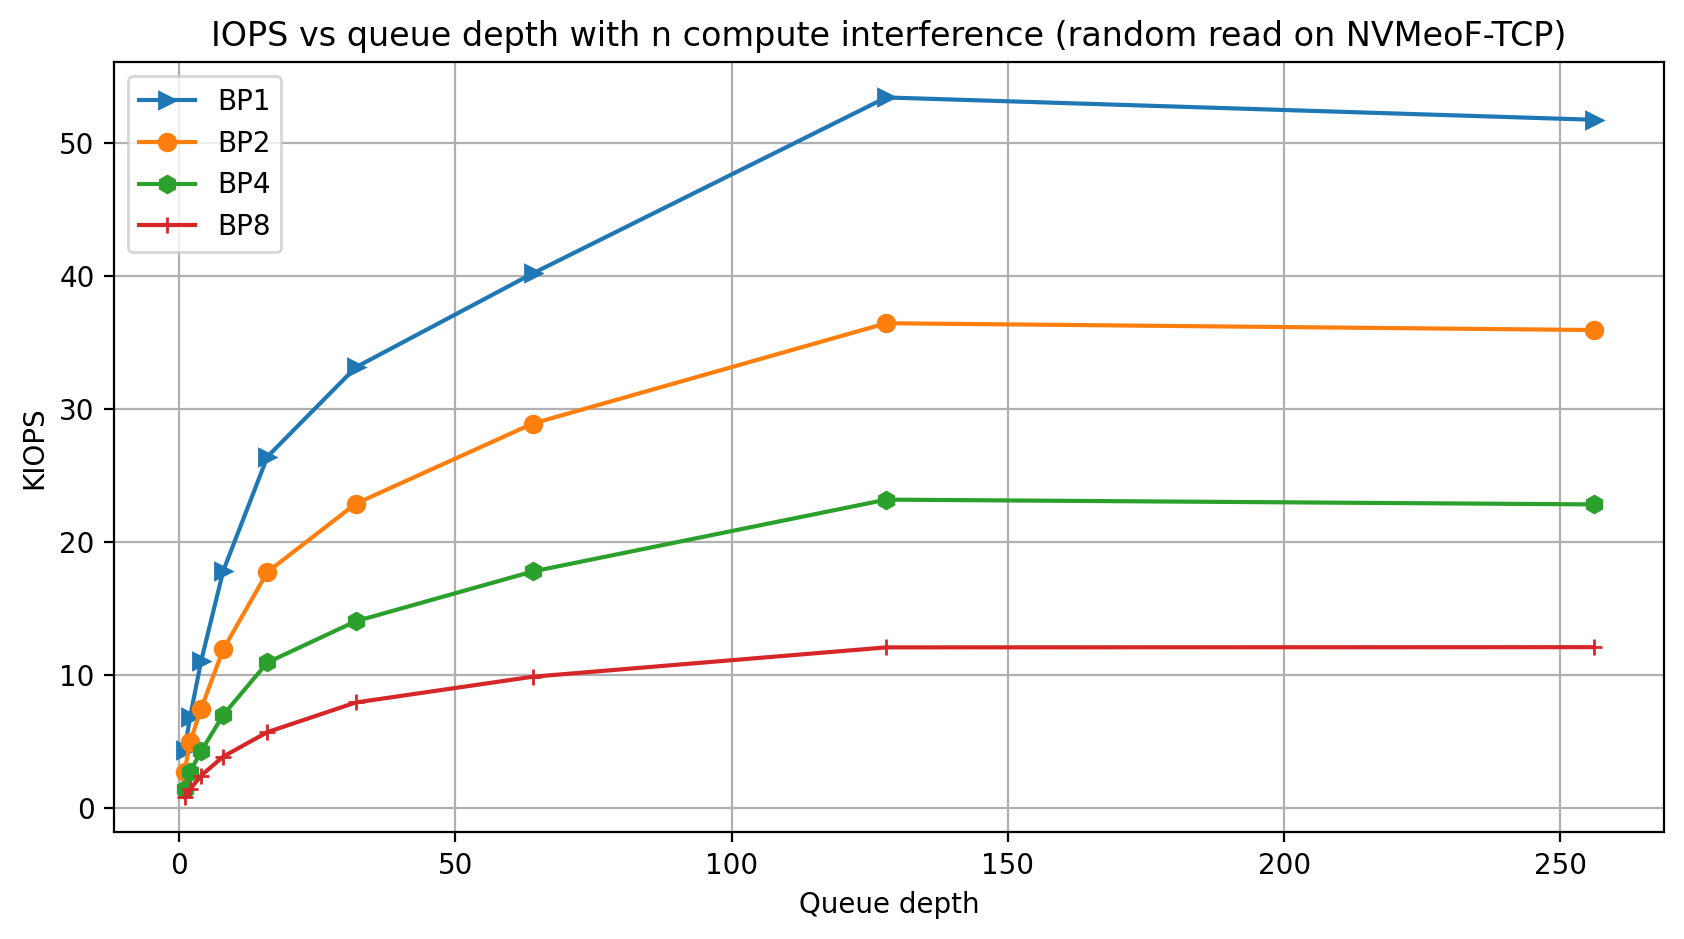

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

for j in PROCESS:
    experiments=[]
    for i in QD:
        experiments.append("remote_compute_SSD_randread_QD{}_BP{}".format(i, j))
    plot_iops_line(experiments, QD, "BP{}".format(j))

#plt.plot(PROCESS, [434 for i in PROCESS],color='black')
plt.title('IOPS vs queue depth with n compute interference (random read on NVMeoF-TCP)')
plt.xlabel("Queue depth")
plt.ylabel('KIOPS')
plt.legend()

KeyError: 'remote_compute_SSD_randread_QD1_BP1'

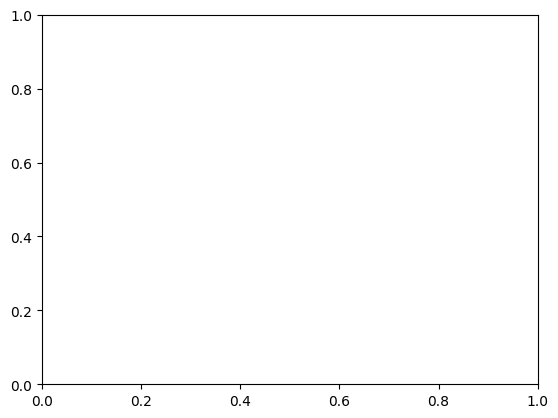

In [32]:
for j in PROCESS:
    plot_lat_percentile("remote_compute_SSD_randread_QD1_BP{}".format(j),"BP{}".format(j),0,1000)
plt.legend()
plt.title("Latency ECDF with compute interference (rand read on NVMeoF-TCP)")

In [ ]:
fig, ax = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
pos = [(0,0), (0,1), (1,0), (1,1)]
index = 0
for j in PROCESS:
    CALLS=0
    for i in [1]:
        plot_lat_percentile("remote_compute_SSD_randread_QD{}_BP{}".format(i,j),"QD{}".format(i),0,1000, ax[pos[index][0], pos[index][1]])
    ax[pos[index][0], pos[index][1]].set_title("{} background process".format(j))
    index += 1

ax[0,0].legend()

#plt.title("ECDF latency distribution for diff fio process (random reads on local)")
fig.text(0.5, -0.04, "Latency ("+u"\u03bc"+"S)", ha='center')
fig.text(-0.01, 0.5, 'ECDF', va='center', rotation='vertical')
fig.suptitle('Latency percentile for N compute interference (rand read NVMeoF-TCP)', fontsize=16)
plt.tight_layout()

{'QD1': [102.912, 4.341361345], 'QD2': [140.288, 6.819722689], 'QD4': [173.056, 11.040848739], 'QD8': [234.496, 17.814537815], 'QD16': [309.248, 26.410084034], 'QD32': [518.144, 33.132722689000005], 'QD64': [937.984, 40.180596639], 'QD128': [1499.136, 53.411184874], 'QD256': [5275.648, 51.734226891]}
{'QD1': [115.2, 2.731319328], 'QD2': [134.144, 4.931907562999999], 'QD4': [183.296, 7.462815126000001], 'QD8': [250.88, 11.923084034], 'QD16': [346.112, 17.741462185], 'QD32': [585.728, 22.880831933], 'QD64': [1028.096, 28.897151260999998], 'QD128': [3489.792, 36.441705882], 'QD256': [6586.368, 35.929764706]}
{'QD1': [129.536, 1.469243697], 'QD2': [148.48, 2.731117647], 'QD4': [207.872, 4.268873950000001], 'QD8': [272.384, 6.992764706], 'QD16': [387.072, 10.941798319], 'QD32': [692.224, 14.042966387], 'QD64': [2637.824, 17.78107563], 'QD128': [4882.432, 23.181966387], 'QD256': [11206.656, 22.823907563000002]}
{'QD1': [136.192, 0.79789916], 'QD2': [166.912, 1.423058824], 'QD4': [220.16, 2.4

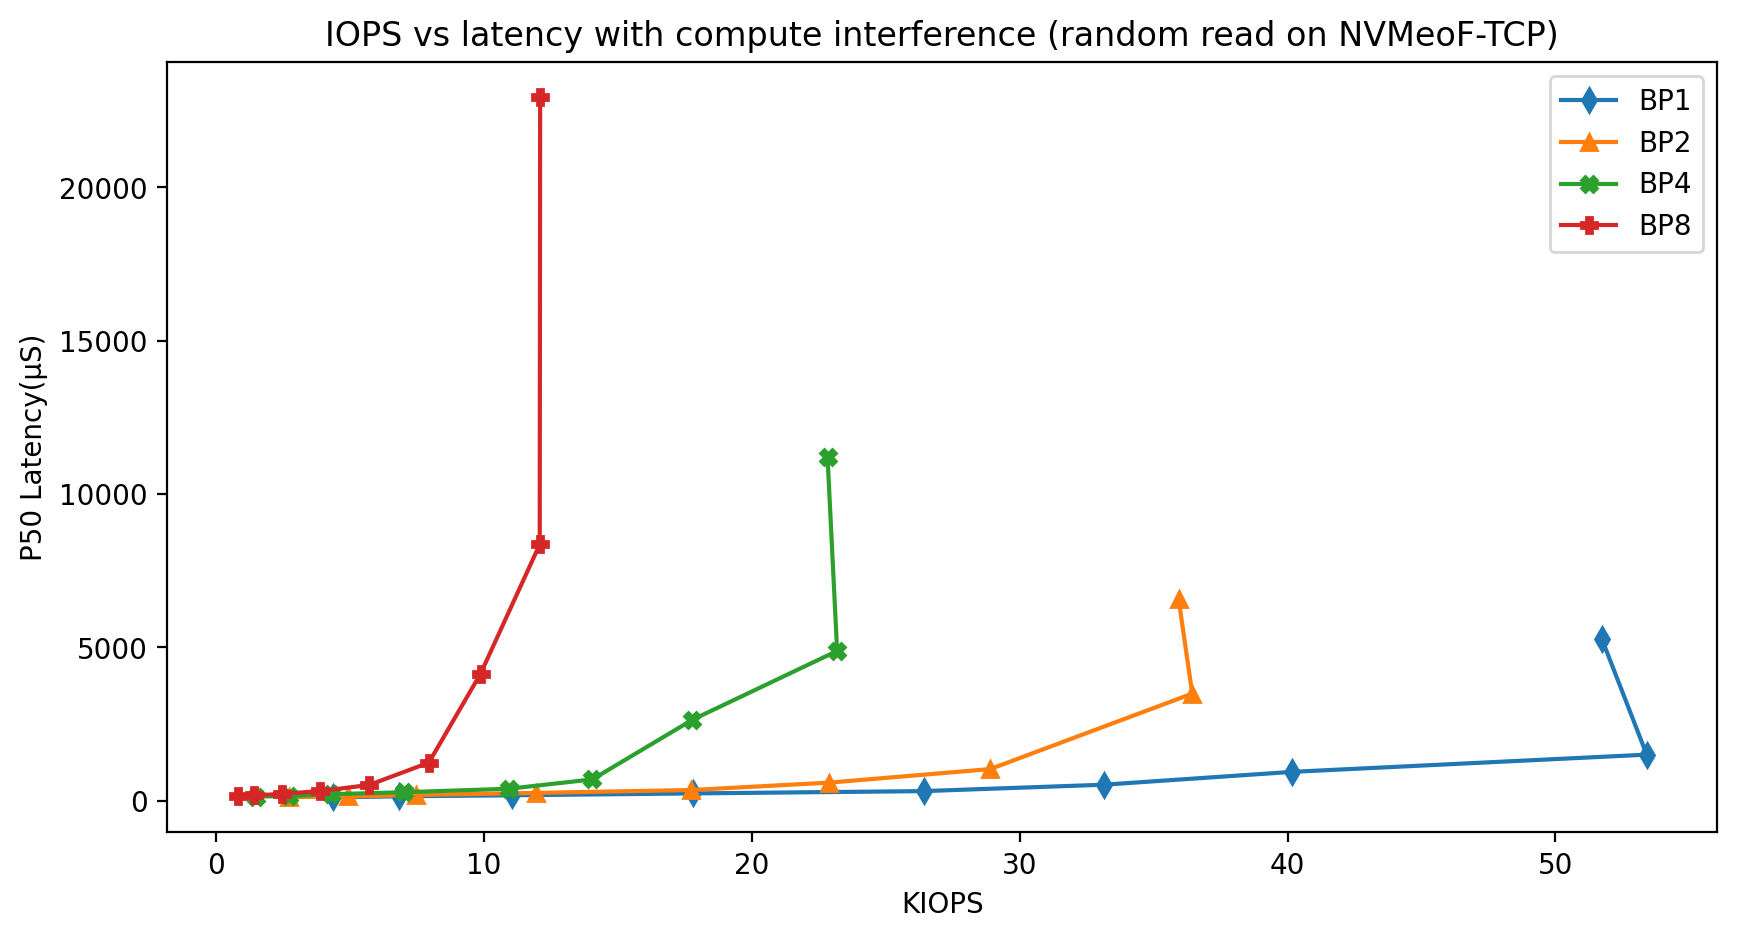

In [29]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
scatter_label = {}
for i in PROCESS:
    names = []
    experiments = []
    for j in QD:
        experiments.append("remote_compute_SSD_randread_QD{}_BP{}".format(j, i))
        names.append("QD{}".format(j))
    d = plot_lat_iops(experiments,50.0,names)
    lat = []
    iops = []
    for k in d.keys():
        lat.append(d[k][0])
        iops.append(d[k][1])
        scatter_label[(d[k][1], d[k][0])] = k
    global CALLS
    mark = MARKERS[CALLS]
    CALLS = (CALLS + 1)%len(MARKERS)
    plt.plot(iops, lat, '-'+mark, label="BP{}".format(i))
    print(d)
    #plt.scatter(iops, lat, marker=mark)

plt.xlabel("KIOPS")
plt.ylabel('P50 Latency(' + u"\u03bc"+ 'S)')
plt.title("IOPS vs latency with compute interference (random read on NVMeoF-TCP)")
plt.legend()

<h1>Timeseries of logs</h1>

Run1 106.415 135.97636874051594
Run2 41.822 63.9823121869783


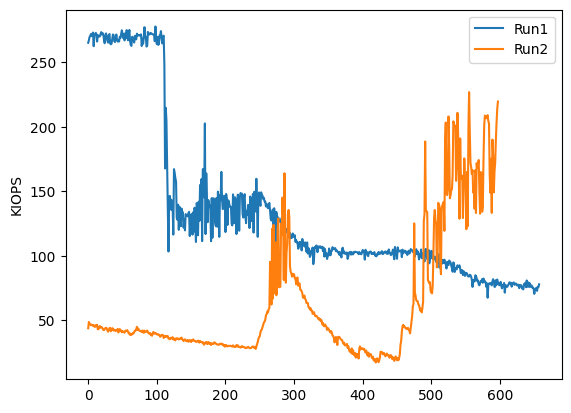

In [13]:
plot_iops_ts("logs/Run1/local_SSD_randwrite_QD32_P1_iops.log","Run1")
plot_iops_ts("logs/local_SSD_randwrite_QD32_P1_iops.log","Run2")
#plot_iops_ts("logs/Run1/local_SSD_randwrite_QD32_P1_iops.log","32")
#plot_iops_ts("logs/local_SSD_randwrite_QD64_P1_iops.log","64")
#plot_iops_ts("logs/local_SSD_randwrite_QD128_P1_iops.log","128")
#plt.xlabel("Time")
plt.ylabel("KIOPS")
plt.legend()

1 13.725
32 247.642
64 340.15
128 367.813


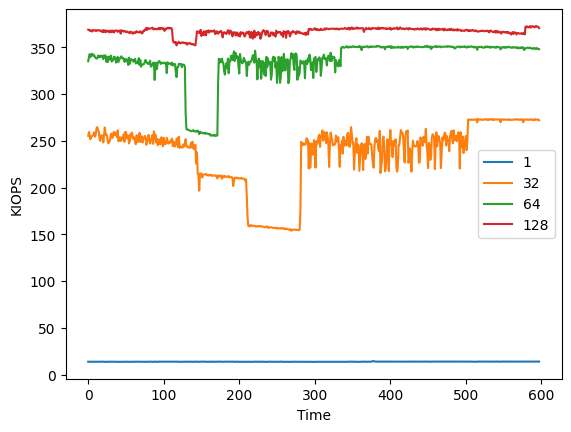

In [33]:
plot_iops_ts("logs/Run1/local_SSD_randread_QD1_P1_iops.log","1")
plot_iops_ts("logs/Run1/local_SSD_randread_QD32_P1_iops.log","32")
plot_iops_ts("logs/Run1/local_SSD_randread_QD64_P1_iops.log","64")
plot_iops_ts("logs/Run1/local_SSD_randread_QD128_P1_iops.log","128")
plt.xlabel("Time")
plt.ylabel("KIOPS")
plt.legend()

1 58.457
32 80.325
64 298.212
128 301.563


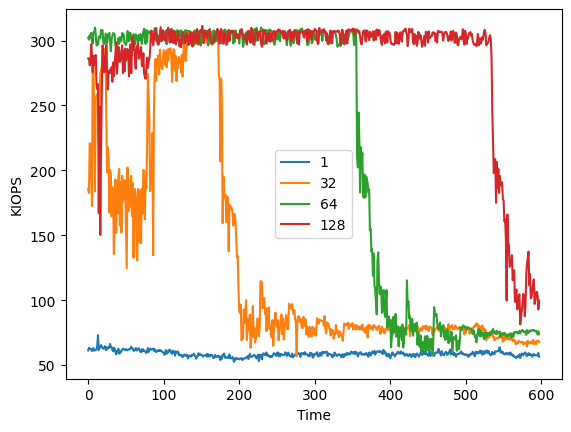

In [35]:
plot_iops_ts("logs/Run1/local_SSD_write_QD1_P1_iops.log","1")
plot_iops_ts("logs/Run1/local_SSD_write_QD32_P1_iops.log","32")
plot_iops_ts("logs/Run1/local_SSD_write_QD64_P1_iops.log","64")
plot_iops_ts("logs/Run1/local_SSD_write_QD128_P1_iops.log","128")
plt.xlabel("Time")
plt.ylabel("KIOPS")
plt.legend()

<h1>QoS</h1>

In [23]:
fp = open("./qos/crunched_numbers_qos.json")
op = json.load(fp)
op.keys()

dict_keys(['remote_share_BP4', 'local_ns_same_core', 'remote_share_BP2', 'local_nice_same_core', 'local_nice_prio_same_core', 'local_ns_diff_core', 'remote_prio_diff_core', 'local_diff_core', 'remote_same_core', 'remote_nice_prio_same_core', 'remote_ns_nice_prio_same_core', 'remote_nice_same_core', 'remote_diff_core', 'local_ns_nice_same_core', 'remote_stonewall', 'remote_ns_stonewall', 'remote_ns_nice_same_core', 'remote_share_BP16', 'local_ns_prio_diff_core', 'local_prio_diff_core', 'remote_ns_same_core', 'remote_share_BP8', 'local_stonewall', 'local_same_core', 'local_ns_nice_prio_same_core', 'remote_ns_prio_diff_core', 'remote_share_BP1', 'local_ns_stonewall', 'remote_ns_diff_core'])

remote_share_BP1 {1.0: 121344.0, 5.0: 144384.0, 10.0: 166912.0, 20.0: 230400.0, 30.0: 276480.0, 40.0: 350208.0, 50.0: 477184.0, 60.0: 659456.0, 70.0: 790528.0, 80.0: 987136.0, 90.0: 1204224.0, 95.0: 1335296.0, 99.0: 1777664.0, 99.5: 2023424.0, 99.9: 3031040.0, 99.95: 3522560.0, 99.99: 5603328.0}
remote_share_BP2 {1.0: 140288.0, 5.0: 201728.0, 10.0: 309248.0, 20.0: 528384.0, 30.0: 667648.0, 40.0: 782336.0, 50.0: 905216.0, 60.0: 1036288.0, 70.0: 1187840.0, 80.0: 1368064.0, 90.0: 1679360.0, 95.0: 2007040.0, 99.0: 3063808.0, 99.5: 3620864.0, 99.9: 5079040.0, 99.95: 5799936.0, 99.99: 8093696.0}
remote_share_BP4 {1.0: 152576.0, 5.0: 313344.0, 10.0: 501760.0, 20.0: 774144.0, 30.0: 995328.0, 40.0: 1220608.0, 50.0: 1466368.0, 60.0: 1744896.0, 70.0: 2113536.0, 80.0: 2670592.0, 90.0: 4177920.0, 95.0: 6389760.0, 99.0: 14614528.0, 99.5: 20054016.0, 99.9: 34340864.0, 99.95: 43253760.0, 99.99: 64749568.0}
remote_share_BP8 {1.0: 193536.0, 5.0: 489472.0, 10.0: 741376.0, 20.0: 1105920.0, 30.0: 1433600.0

Text(0.5, 1.0, 'Latency ECDF with interference from other flows (rand read on NVMeoF-TCP)')

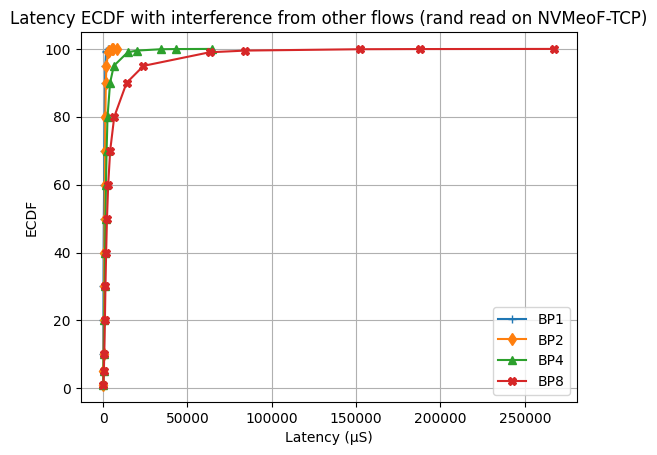

In [31]:
for j in [1,2,4,8]:
    plot_lat_percentile("remote_share_BP{}".format(j),"BP{}".format(j),0,1000)
plt.legend()
plt.xlabel("Latency ("+u"\u03bc"+"S)")
plt.ylabel("ECDF")
plt.title("Latency ECDF with interference from other flows (rand read on NVMeoF-TCP)")

[{'label': 'same core', 'whislo': 31.872, 'q1': 80.384, 'med': 119.296, 'q3': 199.68, 'whishi': 321.536, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 30.848, 'q1': 77.312, 'med': 110.08, 'q3': 183.296, 'whishi': 292.864, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 30.592, 'q1': 76.288, 'med': 105.984, 'q3': 175.104, 'whishi': 276.48, 'fliers': []}]
[{'label': 'different core', 'whislo': 41.216, 'q1': 88.576, 'med': 122.368, 'q3': 193.536, 'whishi': 301.056, 'fliers': []}]
[{'label': 'different core (prio)', 'whislo': 46.848, 'q1': 95.744, 'med': 127.488, 'q3': 193.536, 'whishi': 296.96, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 28.544, 'q1': 29.568, 'med': 30.592, 'q3': 75.264, 'whishi': 87.552, 'fliers': []}]


Text(0.5, 1.0, 'Latency for local L-Flow')

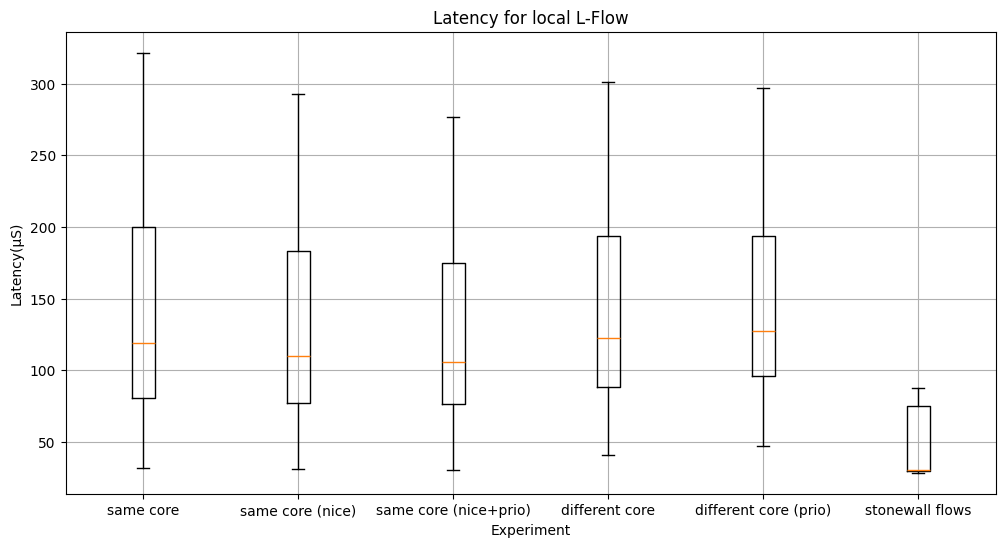

In [11]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

plot_lat_bar("local_same_core_latency","same core", ax, 0)
plot_lat_bar("local_nice_same_core_latency","same core (nice)", ax, 1)
plot_lat_bar("local_nice_prio_same_core_latency", "same core (nice+prio)", ax, 2)
plot_lat_bar("local_diff_core_latency","different core", ax , 3)
plot_lat_bar("local_prio_diff_core_latency","different core (prio)", ax, 4)
plot_lat_bar("local_stonewall_latency", "stonewall flows", ax, 5)
#plt.yscale("log")
plt.title('Latency for local L-Flow')

[{'label': 'same core', 'whislo': 189.44, 'q1': 276.48, 'med': 419.84, 'q3': 708.608, 'whishi': 970.752, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 181.248, 'q1': 268.288, 'med': 399.36, 'q3': 684.032, 'whishi': 921.6, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 187.392, 'q1': 284.672, 'med': 428.032, 'q3': 716.8, 'whishi': 1003.52, 'fliers': []}]
[{'label': 'different core', 'whislo': 72.192, 'q1': 85.504, 'med': 127.488, 'q3': 150.528, 'whishi': 197.632, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 64.256, 'q1': 67.072, 'med': 81.408, 'q3': 122.368, 'whishi': 132.096, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

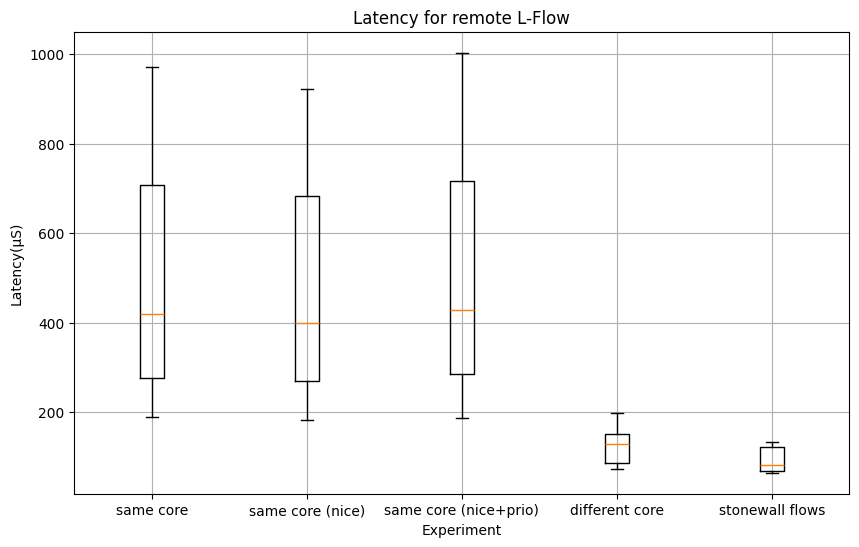

In [12]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_same_core_latency","same core", ax, 0)
plot_lat_bar("remote_nice_same_core_latency","same core (nice)", ax ,1)
#plot_lat_bar("remote_prio_same_core_latency","same core (prio)", ax, 2)
plot_lat_bar("remote_nice_prio_same_core_latency","same core (nice+prio)", ax, 2)
plot_lat_bar("remote_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_stonewall_latency","stonewall flows", ax, 4)
#plt.yscale("log")
plt.title('Latency for remote L-Flow')

[{'label': 'different core', 'whislo': 72.192, 'q1': 85.504, 'med': 127.488, 'q3': 150.528, 'whishi': 197.632, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 64.256, 'q1': 67.072, 'med': 81.408, 'q3': 122.368, 'whishi': 132.096, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

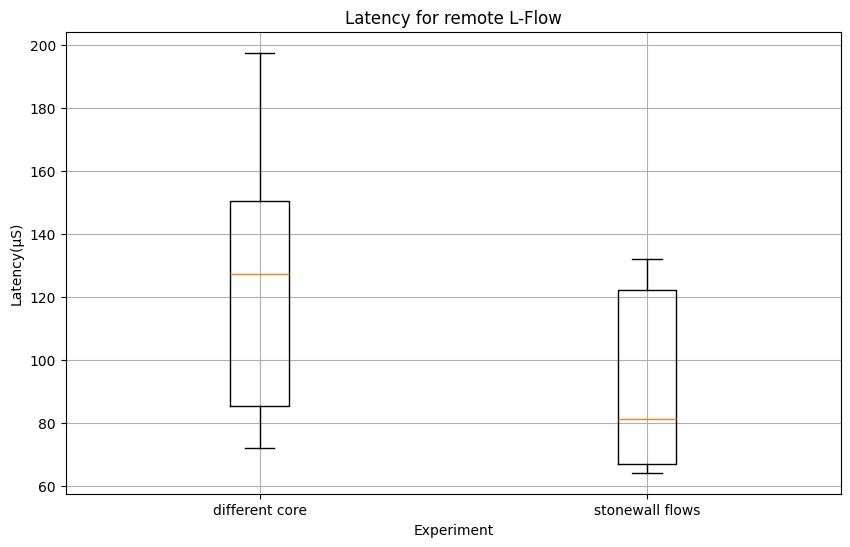

In [13]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_stonewall_latency","stonewall flows", ax, 4)
#plt.yscale("log")
plt.title('Latency for remote L-Flow')

Text(0.5, 1.0, 'IOPS bar graph for local T-Flow')

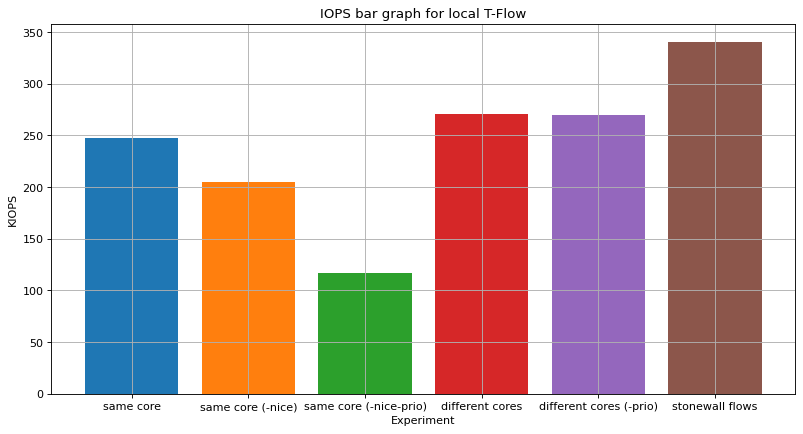

In [6]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("local_same_core_throughput","same core")
plot_iops_bar("local_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("local_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("local_diff_core_throughput","different cores")
plot_iops_bar("local_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("local_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for local T-Flow')


Text(0.5, 1.0, 'IOPS bar graph for remote T-Flow')

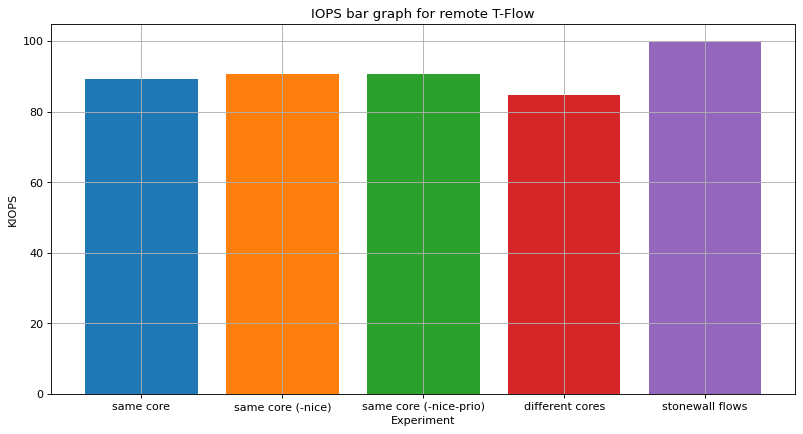

In [7]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("remote_same_core_throughput","same core")
plot_iops_bar("remote_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("remote_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("remote_diff_core_throughput","different cores")
#plot_iops_bar("remote_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("remote_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for remote T-Flow')


[{'label': 'same core', 'whislo': 13.12, 'q1': 13.504, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 13.12, 'q1': 13.376, 'med': 13.888, 'q3': 14.4, 'whishi': 15.936, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 13.12, 'q1': 13.376, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'different core', 'whislo': 14.272, 'q1': 15.68, 'med': 15.936, 'q3': 16.192, 'whishi': 17.024, 'fliers': []}]
[{'label': 'different core (prio)', 'whislo': 14.528, 'q1': 15.68, 'med': 15.936, 'q3': 16.192, 'whishi': 16.768, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 14.272, 'q1': 15.296, 'med': 15.552, 'q3': 15.936, 'whishi': 16.512, 'fliers': []}]


Text(0.5, 1.0, 'Latency for no shared storage local L-Flow')

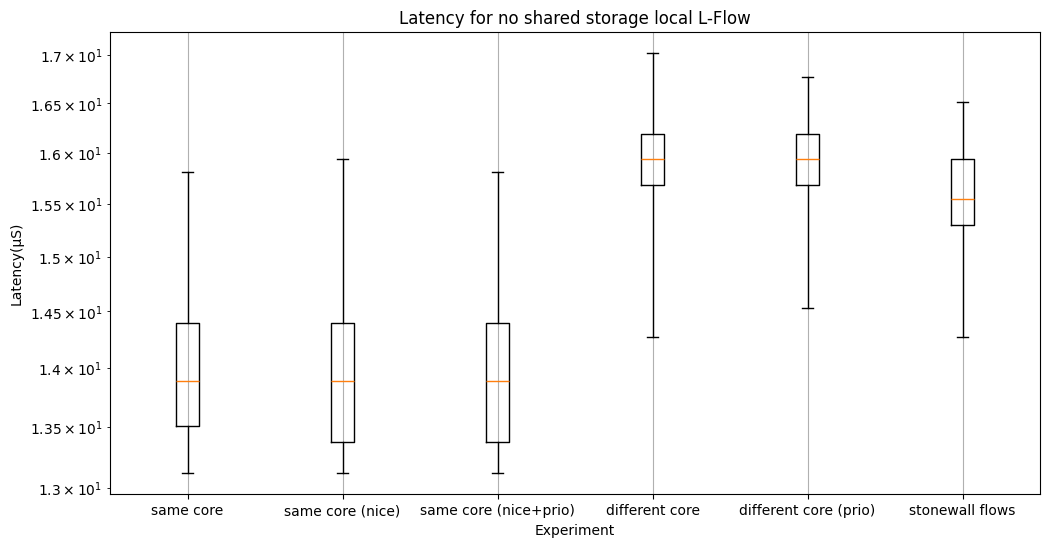

In [8]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)


plot_lat_bar("local_ns_same_core_latency","same core", ax, 0)
plot_lat_bar("local_ns_nice_same_core_latency","same core (nice)", ax, 1)
plot_lat_bar("local_ns_nice_prio_same_core_latency", "same core (nice+prio)", ax, 2)
plot_lat_bar("local_ns_diff_core_latency","different core", ax , 3)
plot_lat_bar("local_ns_prio_diff_core_latency","different core (prio)", ax, 4)
#plot_lat_bar("local_same_stonewall_latency","stonewall flows (same)", ax, 5)
plot_lat_bar("local_ns_stonewall_latency", "stonewall flows", ax, 5)
plt.yscale("log")
plt.title('Latency for no shared storage local L-Flow')

[{'label': 'same core', 'whislo': 569.344, 'q1': 724.992, 'med': 806.912, 'q3': 929.792, 'whishi': 1187.84, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 399.36, 'q1': 651.264, 'med': 749.568, 'q3': 847.872, 'whishi': 1073.152, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 387.072, 'q1': 651.264, 'med': 741.376, 'q3': 847.872, 'whishi': 1073.152, 'fliers': []}]
[{'label': 'different core', 'whislo': 49.92, 'q1': 51.456, 'med': 53.504, 'q3': 57.088, 'whishi': 64.256, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 48.896, 'q1': 50.944, 'med': 52.48, 'q3': 56.576, 'whishi': 64.768, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

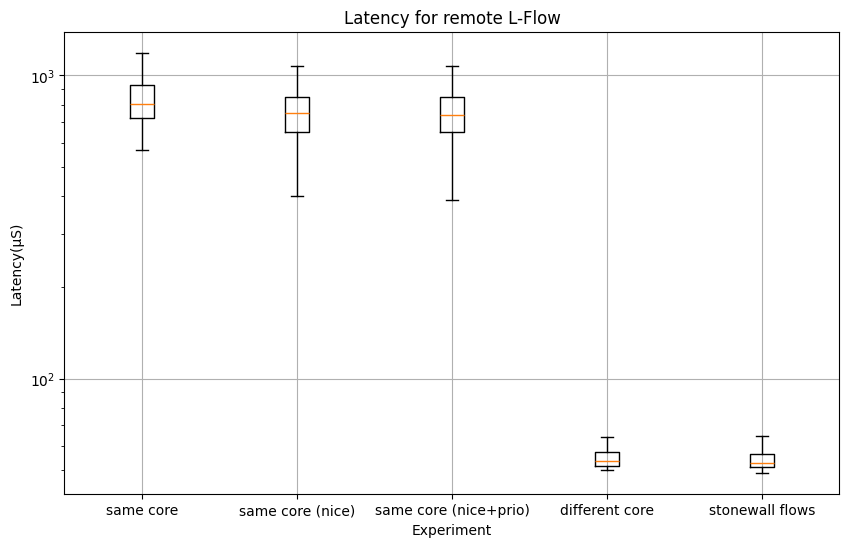

In [9]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_ns_same_core_latency","same core", ax, 0)
plot_lat_bar("remote_ns_nice_same_core_latency","same core (nice)", ax ,1)
#plot_lat_bar("remote_prio_same_core_latency","same core (prio)", ax, 2)
plot_lat_bar("remote_ns_nice_prio_same_core_latency","same core (nice+prio)", ax, 2)
plot_lat_bar("remote_ns_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_ns_stonewall_latency","stonewall flows", ax, 4)
plt.yscale("log")
plt.title('Latency for remote L-Flow')

[{'label': 'Shared compute only', 'whislo': 13.12, 'q1': 13.504, 'med': 13.888, 'q3': 14.4, 'whishi': 15.808, 'fliers': []}]
[{'label': 'Shared storage and compute', 'whislo': 11.968, 'q1': 12.736, 'med': 14.528, 'q3': 20.096, 'whishi': 62.208, 'fliers': []}]


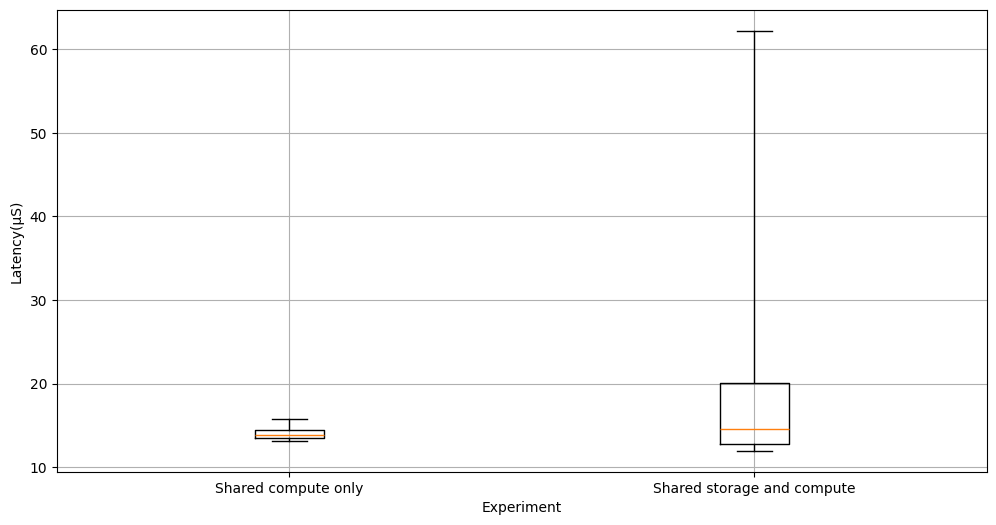

In [10]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("local_ns_same_core_latency","Shared compute only", ax, 0)
plot_lat_bar("local_same_core_latency","Shared storage and compute", ax, 1)

[{'label': 'Shared compute and network', 'whislo': 569.344, 'q1': 724.992, 'med': 806.912, 'q3': 929.792, 'whishi': 1187.84, 'fliers': []}]
[{'label': 'Shared storage, network and compute', 'whislo': 148.48, 'q1': 280.576, 'med': 602.112, 'q3': 798.72, 'whishi': 1056.768, 'fliers': []}]


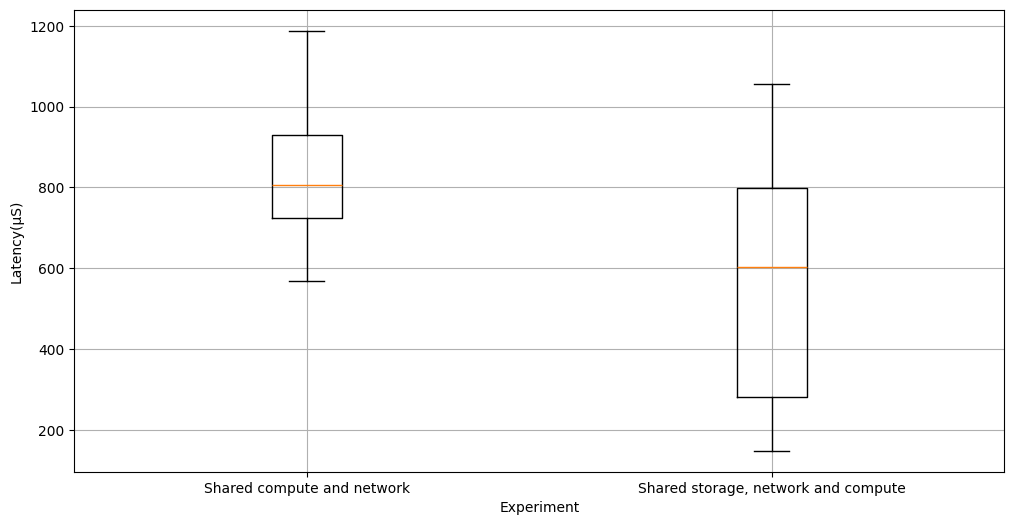

In [14]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("remote_ns_same_core_latency","Shared compute and network", ax, 0)
plot_lat_bar("remote_same_core_latency","Shared storage, network and compute", ax, 1)

[{'label': 'Shared network only', 'whislo': 49.92, 'q1': 51.456, 'med': 53.504, 'q3': 57.088, 'whishi': 64.256, 'fliers': []}]
[{'label': 'Shared storage and network', 'whislo': 51.968, 'q1': 54.528, 'med': 58.112, 'q3': 65.28, 'whishi': 98.816, 'fliers': []}]


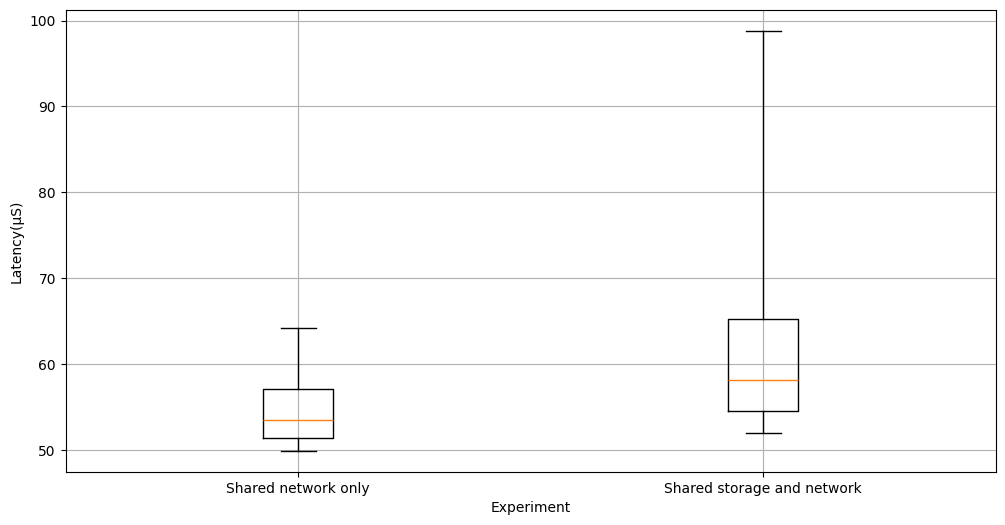

In [13]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("remote_ns_diff_core_latency","Shared network only", ax, 0)
plot_lat_bar("remote_diff_core_latency","Shared storage and network", ax, 1)

In [3]:
fp = open("./performance/crunched_numbers_performance.json")
op = json.load(fp)

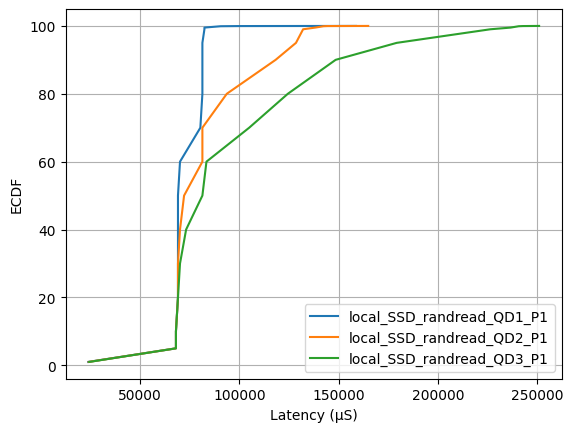

In [6]:
plot_lat_percentile("local_SSD_randread_QD1_P1")
plot_lat_percentile("local_SSD_randread_QD2_P1")
plot_lat_percentile("local_SSD_randread_QD3_P1")

[{'label': 'QD1', 'whislo': 68.096, 'q1': 69.12, 'med': 69.12, 'q3': 81.408, 'whishi': 81.408, 'fliers': []}]
[{'label': 'QD2', 'whislo': 68.096, 'q1': 69.12, 'med': 72.192, 'q3': 93.696, 'whishi': 128.512, 'fliers': []}]
[{'label': 'QD3', 'whislo': 68.096, 'q1': 69.12, 'med': 81.408, 'q3': 124.416, 'whishi': 179.2, 'fliers': []}]


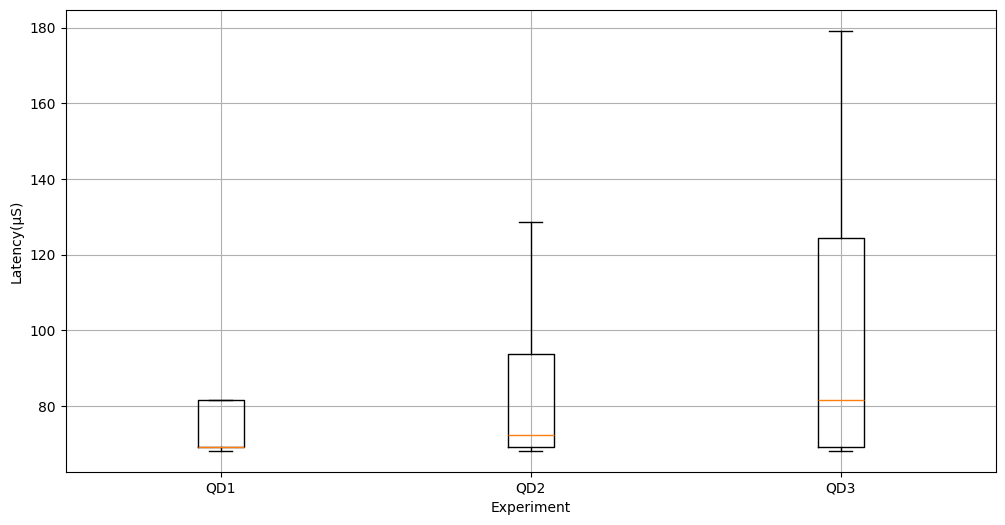

In [8]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
plot_lat_bar("local_SSD_randread_QD1_P1","QD1",ax,0)
plot_lat_bar("local_SSD_randread_QD2_P1","QD2",ax,1)
plot_lat_bar("local_SSD_randread_QD3_P1","QD3",ax,2)